# 🧩 Clustering I — K-Means and Hierarchical Clustering

> **What you'll learn:** how to find groups in data that has no labels. You will watch K-Means move its centroids step by step, measure why k-means++ initialization matters, choose the number of clusters with evidence (elbow, silhouette, gap statistic), see K-Means fail on purpose, build dendrograms with every linkage, judge clusterings with internal and external metrics, and turn clusters into business segments that people can act on.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Ensembles: Voting, Stacking & AdaBoost](11_Ensembles_Voting_Stacking_AdaBoost.ipynb) (the previous notebook in the series) · [Scikit-Learn](02_Scikit_Learn.ipynb) (pipelines, scaling, and the short KMeans/DBSCAN preview in Section 11) |
| **Tested with** | Python 3.12 · scikit-learn 1.9 · scipy 1.18 · numpy 2.5 · pandas 3.0 · seaborn 0.13 · matplotlib 3.11 |
| **Interview relevance** | ⭐⭐⭐ High — "how do you choose k?", "why does K-Means converge?", k-means++, "why scale before K-Means?", linkage types, silhouette vs ARI, "implement K-Means in NumPy", customer segmentation case studies |

## 🤔 What Is Clustering?

Imagine you empty a big box of **mixed LEGO bricks** onto the floor. Nobody tells you what the "right" groups are. You still start sorting: small red bricks here, long flat grey ones there, wheels in their own pile. You grouped things **because they look alike**, not because a label told you.

**Clustering** is exactly that for data: put rows that are **similar** into the same group (a **cluster**) and rows that are **different** into different groups, **without any labels**. It is the most common kind of **unsupervised learning** (learning from inputs `X` only, with no target `y`).

This notebook covers the two classic families:

```
K-Means (partitioning)                      Hierarchical (agglomerative)
─────────────────────────                   ──────────────────────────────
pick k centres ●                            start: every point is its own cluster
repeat:                                     repeat: merge the two closest clusters
  1. each point joins its nearest centre              ┌──────┴──────┐
  2. each centre moves to its points' mean         ┌──┴──┐       ┌──┴──┐
until nothing changes                             a     b       c    ┌┴┐
                                                                     d e
output: k flat groups + k centres           output: a whole tree (dendrogram) you can cut at any level
```

- A **centroid** is the average position of the points in a cluster.
- **Similar** almost always means *close in distance*, usually **Euclidean distance** (the straight-line distance).
- The next notebook covers clustering by **density** (DBSCAN, HDBSCAN) and by **probability** (Gaussian mixtures).

## 🎯 Why It Matters

- **Customer segmentation.** Marketing, pricing and product teams group customers by behaviour ("bulk grocery buyers", "small cafés") to target offers. You will build this in the mini project.
- **Exploring new data.** Before any model exists, clustering shows what kinds of rows are in a dataset and finds odd groups (data errors, fraud rings, new user types).
- **Features and compression.** Distance to each centroid is a strong feature for supervised models. Colour quantization and **vector quantization** (the "IVF" index inside vector databases such as FAISS) are K-Means under the hood.
- **Hierarchies.** Biology (gene expression, species trees), document taxonomies and product catalogues are naturally trees, which is what agglomerative clustering builds.
- **In interviews** clustering is a standard topic: *"How do you choose k?"*, *"Why does K-Means need scaling?"*, *"What does k-means++ do?"*, *"When does K-Means fail?"*, *"Single vs complete vs Ward linkage?"*, *"How do you evaluate clusters without labels?"*, *"Implement K-Means in NumPy"*, and case studies like *"segment our customers"*. This notebook practises all of them.

## 🃏 Algorithm Card

| | **K-Means** (`KMeans`, `MiniBatchKMeans`) | **Hierarchical agglomerative** (`AgglomerativeClustering`, `scipy.cluster.hierarchy`) |
|---|---|---|
| **Learning type** | Unsupervised | Unsupervised |
| **Tasks** | Clustering, vector quantization, centroid-distance features | Clustering, building a hierarchy/taxonomy, regionalization (with connectivity) |
| **Model / objective** | Minimize **inertia** (within-cluster sum of squares) $\sum_i \lVert x_i - \mu_{c_i} \rVert^2$ with Lloyd's algorithm | Greedy bottom-up merging; the **linkage** defines cluster distance (single = min, complete = max, average = mean, **Ward** = smallest increase in within-cluster SSE) |
| **Key hyperparameters (typical ranges)** | `n_clusters` (2–20, choose with elbow/silhouette/gap), `init="k-means++"`, `n_init` (1–10), `max_iter` (300) | `linkage` (`ward`, `complete`, `average`, `single`), `n_clusters` **or** `distance_threshold`, `metric`, `connectivity` (kNN graph, 5–20 neighbours) |
| **Needs feature scaling?** | **Yes** — Euclidean distance lets large-unit features dominate | **Yes** — every linkage is built on distances |
| **Handles missing values / categoricals?** | No / No — impute; encode categoricals (or use k-modes/k-prototypes) | No / No — impute; for categoricals use a precomputed distance (e.g. Gower) with `average`/`complete` linkage |
| **Training & prediction complexity** | $O(n \cdot k \cdot d)$ per iteration, memory $O(n d)$; predict $O(k d)$ per point | $O(n^2)$ memory and about $O(n^2)$–$O(n^3)$ time (fast algorithms exist for single/Ward); **no `predict`** for new points |
| **Interpretability** | High — each cluster is summarized by its centroid | High for small $n$ — the dendrogram shows how and when groups merge |
| **Strengths** | Fast, scales to millions of rows (MiniBatch), simple, assigns new points | No need to fix k up front, shows structure at every scale, any linkage/metric, connectivity constraints |
| **Weaknesses** | Must pick k; assumes round, similar-size clusters; sensitive to scale, outliers and initialization | Slow and memory-hungry beyond ~20k rows; greedy merges can't be undone; single linkage chains |
| **Use it when** | Many rows, numeric features, compact blob-like groups, you need centroids or fast assignment | A few thousand rows, you want a tree or don't know k, you need spatially contiguous regions |
| **Avoid it when** | Clusters are elongated/nested, densities differ a lot, lots of outliers (see DBSCAN/HDBSCAN next) | Hundreds of thousands of rows, or you need to assign new points in production |
| **Best libraries** | scikit-learn (`KMeans`, `MiniBatchKMeans`, `BisectingKMeans`); FAISS for billions of vectors | scikit-learn, SciPy (`linkage`, `dendrogram`, `fcluster`, `cophenet`) |

## ✅ By the End You Can

- [ ] Explain the K-Means objective, run Lloyd's algorithm by hand, and prove why it always converges (to a *local* minimum)
- [ ] Explain k-means++ and measure its effect against random initialization
- [ ] Choose k with the elbow, silhouette and gap statistic, and explain why they may disagree
- [ ] Predict and demonstrate when K-Means fails (scaling, shapes, sizes, densities) and choose a better tool
- [ ] Build and cut dendrograms with single, complete, average and Ward linkage, including connectivity constraints
- [ ] Evaluate clusters with silhouette, Davies–Bouldin, Calinski–Harabasz, ARI and NMI, and profile segments for a business audience
- [ ] Implement K-Means (with k-means++) and agglomerative clustering from scratch and match the libraries exactly

## 📋 Table of Contents

1. [Unsupervised Learning: Why Evaluation Is Hard](#1.-Unsupervised-Learning:-Why-Evaluation-Is-Hard-🟢)
2. [The K-Means Objective and Lloyd's Algorithm](#2.-The-K-Means-Objective-and-Lloyd's-Algorithm-🟢)
3. [K-Means++ vs Random Initialization](#3.-K-Means++-vs-Random-Initialization-🟡)
4. [Choosing k: Elbow, Silhouette, and Gap Statistic](#4.-Choosing-k:-Elbow,-Silhouette,-and-Gap-Statistic-🟡)
5. [Scaling Matters](#5.-Scaling-Matters-🟢)
6. [Assumptions and Failure Modes](#6.-Assumptions-and-Failure-Modes-🟡)
7. [MiniBatchKMeans for Large Data](#7.-MiniBatchKMeans-for-Large-Data-🟡)
8. [Hierarchical Agglomerative Clustering and Linkages](#8.-Hierarchical-Agglomerative-Clustering-and-Linkages-🟡)
9. [Dendrograms, Cutting the Tree, and Connectivity](#9.-Dendrograms,-Cutting-the-Tree,-and-Connectivity-🟡)
10. [Internal vs External Evaluation Metrics](#10.-Internal-vs-External-Evaluation-Metrics-🟡)
11. [Profiling and Interpreting Clusters](#11.-Profiling-and-Interpreting-Clusters-🟢)
12. [A Fair Head-to-Head Comparison](#12.-A-Fair-Head-to-Head-Comparison-🔴)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Wholesale-Customer-Segmentation) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a library is missing, uncomment the `%pip` line, run it once, then restart the kernel.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

**Datasets (all real, downloaded once and cached, about 12 MB in total):**
- **Palmer penguins** (via seaborn, cached in `_outputs/`): 333 penguins with 4 body measurements and their true species. We *hide* the species while clustering and use it only to grade the result.
- **Handwritten digits** (built into scikit-learn): 1,797 images of 8×8 pixels.
- **Forest cover type** (scikit-learn downloader, ~11 MB): 581,012 forest patches, for the large-data section.
- **California housing** (scikit-learn downloader): district coordinates, for connectivity-constrained clustering.
- **UCI Wholesale customers** (OpenML dataset 1511): annual spending of 440 clients of a Portuguese wholesale distributor, for the mini project.

In [1]:
# %pip install -q "scikit-learn>=1.6" "scipy>=1.13" "pandas>=2.2" "seaborn>=0.13" matplotlib

import gc
import sys
import time
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn
from scipy.cluster.hierarchy import cophenet, dendrogram, fcluster, linkage
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import pdist
from scipy.stats import spearmanr
from sklearn.cluster import AgglomerativeClustering, BisectingKMeans, KMeans, MiniBatchKMeans, kmeans_plusplus
from sklearn.datasets import (fetch_california_housing, fetch_covtype, fetch_openml, load_digits, load_wine,
                              make_blobs, make_moons)
from sklearn.metrics import (adjusted_mutual_info_score, adjusted_rand_score, calinski_harabasz_score,
                             davies_bouldin_score, normalized_mutual_info_score, rand_score, silhouette_samples,
                             silhouette_score)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.neighbors import NearestCentroid, NearestNeighbors, kneighbors_graph
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, RobustScaler, StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text

print(f"Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__} | scipy {scipy.__version__} | "
      f"numpy {np.__version__} | pandas {pd.__version__} | seaborn {sns.__version__} | matplotlib {matplotlib.__version__}")

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.precision", 3)
pd.set_option("display.width", 140)
OUTPUT_DIR = Path("_outputs")              # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(exist_ok=True)


def check(name, got, expected, hint="", rtol=1e-4, atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, dict):
        ok = isinstance(got, dict) and set(got) == set(expected) and all(
            np.allclose(got[k], expected[k], rtol=rtol, atol=atol) for k in expected)
    elif isinstance(expected, (bool, np.bool_, str)):
        ok = got == expected
    else:
        try:
            g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        except (TypeError, ValueError):
            raise AssertionError(f"❌ {name}: expected a number/array, got {type(got).__name__}. {hint}")
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, rtol=rtol, atol=atol)
    assert ok, f"❌ {name}: not quite. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | scikit-learn 1.9.1 | scipy 1.18.1 | numpy 2.5.3 | pandas 3.0.5 | seaborn 0.13.2 | matplotlib 3.11.2


## 1. Unsupervised Learning: Why Evaluation Is Hard 🟢

| | **Supervised** (notebooks 03–11) | **Unsupervised** (this notebook) |
|---|---|---|
| Data | features `X` **and** a target `y` | features `X` only |
| Goal | predict `y` for new rows | discover structure: groups, directions, odd points |
| "Correct" answer | yes — compare predictions with `y` | **no answer key** |
| Typical score | accuracy, RMSE, ROC-AUC on a test set | internal metrics, stability, and *usefulness* to a person |

**Why evaluation is hard:** the same data can be grouped in several sensible ways. Penguins could be grouped by **species**, by **sex**, or by **island**, and each is "right" for a different question. A clustering algorithm doesn't know your question. So we judge clusters in four ways:

1. **Internal metrics** — are clusters compact and well separated? (silhouette, Davies–Bouldin, Calinski–Harabasz; Section 10)
2. **External metrics** — if some labels exist *for checking only*, do clusters agree with them? (ARI, NMI)
3. **Stability** — do we get the same clusters on a slightly different sample?
4. **Usefulness** — can a person describe and act on each cluster? (Section 11 and the mini project)

Let's see the problem on real data. We load the **Palmer penguins** and hide the species.

In [2]:
penguins = sns.load_dataset("penguins", data_home=str(OUTPUT_DIR / "seaborn-data")).dropna().reset_index(drop=True)
PENGUIN_FEATURES = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X_peng = penguins[PENGUIN_FEATURES].to_numpy()
X_peng_s = StandardScaler().fit_transform(X_peng)        # scaling is explained in Section 5
species = penguins["species"].to_numpy()
print(f"{len(penguins)} penguins | species counts: {penguins['species'].value_counts().to_dict()}")
print(penguins.head(3))

labels_k2 = KMeans(n_clusters=2, random_state=SEED).fit_predict(X_peng_s)
labels_k3 = KMeans(n_clusters=3, random_state=SEED).fit_predict(X_peng_s)
first_look = pd.DataFrame({
    "silhouette (higher = tighter clusters)": [silhouette_score(X_peng_s, labels_k2), silhouette_score(X_peng_s, labels_k3)],
    "ARI vs species": [adjusted_rand_score(species, labels_k2), adjusted_rand_score(species, labels_k3)],
    "ARI vs sex": [adjusted_rand_score(penguins["sex"], labels_k2), adjusted_rand_score(penguins["sex"], labels_k3)],
}, index=["K-Means k=2", "K-Means k=3"])
print(first_look.round(3))

333 penguins | species counts: {'Adelie': 146, 'Gentoo': 119, 'Chinstrap': 68}
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g     sex
0  Adelie  Torgersen            39.1           18.7              181.0       3750.0    Male
1  Adelie  Torgersen            39.5           17.4              186.0       3800.0  Female
2  Adelie  Torgersen            40.3           18.0              195.0       3250.0  Female
             silhouette (higher = tighter clusters)  ARI vs species  ARI vs sex
K-Means k=2                                   0.531           0.649      -0.003
K-Means k=3                                   0.446           0.799       0.023


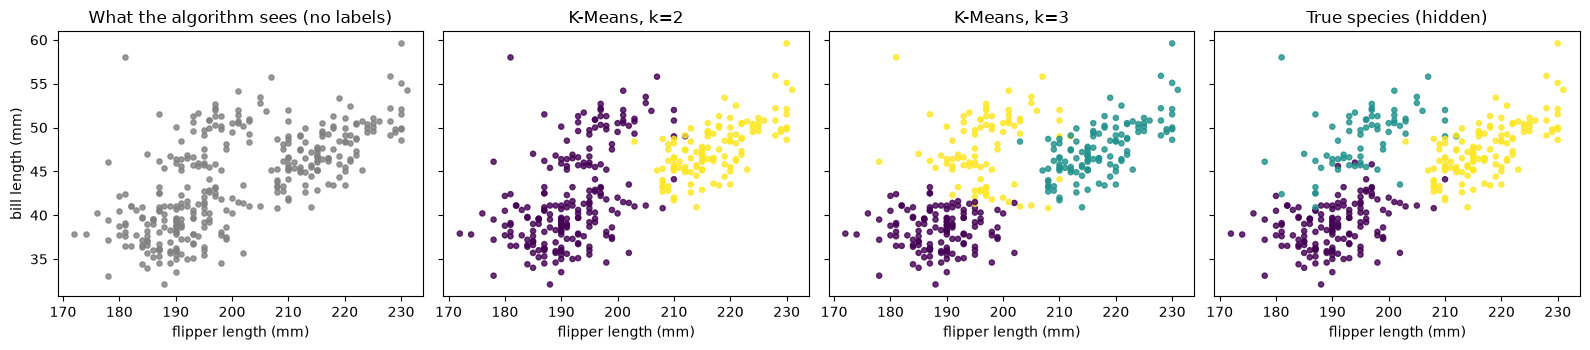

Silhouette prefers 'K-Means k=2', but 'K-Means k=3' agrees best with species (ARI 0.799). Both ignore sex (|ARI| ≤ 0.023).
→ There is no single 'correct' clustering: the geometry favours one answer, the biology question another.


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharex=True, sharey=True)
panels = [(None, "What the algorithm sees (no labels)"), (labels_k2, "K-Means, k=2"),
          (labels_k3, "K-Means, k=3"), (pd.factorize(species)[0], "True species (hidden)")]
for ax, (colour, title) in zip(axes, panels):
    style = {"color": "grey"} if colour is None else {"c": colour, "cmap": "viridis"}
    ax.scatter(penguins["flipper_length_mm"], penguins["bill_length_mm"], s=14, alpha=0.8, **style)
    ax.set(title=title, xlabel="flipper length (mm)")
axes[0].set_ylabel("bill length (mm)")
plt.tight_layout()
plt.show()

best_sil = first_look.iloc[:, 0].idxmax()
best_species = first_look["ARI vs species"].idxmax()
print(f"Silhouette prefers '{best_sil}', but '{best_species}' agrees best with species "
      f"(ARI {first_look.loc[best_species, 'ARI vs species']:.3f}). Both ignore sex (|ARI| ≤ {first_look['ARI vs sex'].abs().max():.3f}).")
print("→ There is no single 'correct' clustering: the geometry favours one answer, the biology question another.")

The **ARI** (adjusted Rand index, Section 10) is 1 for perfect agreement with the reference labels and about 0 for random labels. Notice two things:
- Gentoo penguins are very different from the other two species, so **two** groups are the tightest split. Adelie and Chinstrap overlap a lot in these measurements.
- Cluster IDs are **arbitrary names**. "Cluster 0" in one run can be "cluster 2" in the next run. That is why we compare clusterings with ARI, never with `==`.

### ✍️ Your Turn

Two runs gave the labellings `run_a` and `run_b` below. Compute their **adjusted Rand index** with scikit-learn. Are they the same clustering?

In [4]:
run_a = [0, 0, 1, 1, 2, 2]
run_b = [2, 2, 0, 0, 1, 1]
ari_runs = None  # TODO: your code here
check("ari_runs", ari_runs, 1.0, hint="adjusted_rand_score(run_a, run_b) — it ignores what the clusters are called.")

⏳ ari_runs: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
run_a = [0, 0, 1, 1, 2, 2]
run_b = [2, 2, 0, 0, 1, 1]
ari_runs = adjusted_rand_score(run_a, run_b)
check("ari_runs", ari_runs, 1.0)
```

ARI = 1.0: the two runs put exactly the same points together, they just use different names. `np.mean(np.array(run_a) == np.array(run_b))` would say 0% agreement, which is wrong.
</details>

> 💡 **Interview angle:** "How do you evaluate a clustering without labels?" — combine internal metrics (silhouette, Davies–Bouldin), stability across resamples, and whether domain experts can name and use each cluster. If a few labelled examples exist, use them *only* for checking, with ARI/NMI, which ignore cluster names.

## 2. The K-Means Objective and Lloyd's Algorithm 🟢

**Intuition.** Place $k$ flags (centroids) on a map. Every house joins its nearest flag. Then move each flag to the middle of its houses. Repeat until no house changes flag.

**The objective.** K-Means looks for cluster assignments $c_i$ and centroids $\mu_1, \dots, \mu_k$ that minimize the **inertia**, also called the **within-cluster sum of squares (WCSS)**:

$$J = \sum_{i=1}^{n} \lVert x_i - \mu_{c_i} \rVert^2$$

**Lloyd's algorithm** alternates two steps, and **neither step can increase $J$**:

1. **Assignment step:** $c_i = \arg\min_j \lVert x_i - \mu_j \rVert^2$. Each point picks its closest centroid, so its own term in $J$ can only go down or stay the same.
2. **Update step:** $\mu_j = \frac{1}{|S_j|} \sum_{i \in S_j} x_i$ (the mean of the points in cluster $j$). The mean is the point that minimizes the sum of squared distances. Set the derivative to zero: $\frac{\partial}{\partial \mu}\sum_{i \in S_j} \lVert x_i - \mu \rVert^2 = -2 \sum_{i \in S_j} (x_i - \mu) = 0 \Rightarrow \mu = \text{mean}$.

**Why it always converges:** $J$ never increases and there are only finitely many ways to split $n$ points into $k$ groups, so the algorithm must stop. But it stops at a **local** minimum. Finding the global minimum is NP-hard, which is why the starting centroids matter (Section 3).

**Cost:** each iteration computes $n \times k$ distances in $d$ dimensions, $O(nkd)$.

Let's animate it as static frames on two penguin measurements, starting from three deliberately *bad* centroids.

In [5]:
X2 = StandardScaler().fit_transform(penguins[["flipper_length_mm", "bill_length_mm"]])
centers = X2[[0, 1, 2]].copy()            # three Adelie penguins (rows 0–2) as starting centroids: a poor start
frames, history = [], []
labels = None
for step in range(20):
    sq_dist = ((X2[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)      # (n, k) squared distances
    new_labels = sq_dist.argmin(axis=1)                                     # 1. assignment step
    history.append(("after assignment", step, sq_dist[np.arange(len(X2)), new_labels].sum()))
    if labels is not None and np.array_equal(new_labels, labels):
        break                                                               # nobody moved → converged
    labels = new_labels
    frames.append((centers.copy(), labels.copy()))
    centers = np.array([X2[labels == j].mean(axis=0) for j in range(3)])    # 2. update step
    history.append(("after update", step, ((X2 - centers[labels]) ** 2).sum()))

objective = [h[2] for h in history]
for kind, step, value in history[:8]:
    print(f"iteration {step} {kind:17s} inertia = {value:8.3f}")
print(f"... converged after {len(frames)} update steps | final inertia {objective[-1]:.3f}")
assert all(b <= a + 1e-9 for a, b in zip(objective, objective[1:])), "inertia went up — impossible for Lloyd's algorithm"
print("✅ inertia never increased")

sk_same_start = KMeans(n_clusters=3, init=X2[[0, 1, 2]], n_init=1).fit(X2)
print(f"scikit-learn from the same start: inertia {sk_same_start.inertia_:.3f} "
      f"| same clusters: {adjusted_rand_score(sk_same_start.labels_, labels) == 1.0}")

iteration 0 after assignment  inertia =  825.608
iteration 0 after update      inertia =  359.582
iteration 1 after assignment  inertia =  273.584
iteration 1 after update      inertia =  245.737
iteration 2 after assignment  inertia =  235.913
iteration 2 after update      inertia =  231.632
iteration 3 after assignment  inertia =  228.762
iteration 3 after update      inertia =  227.468
... converged after 20 update steps | final inertia 154.845
✅ inertia never increased
scikit-learn from the same start: inertia 154.845 | same clusters: True


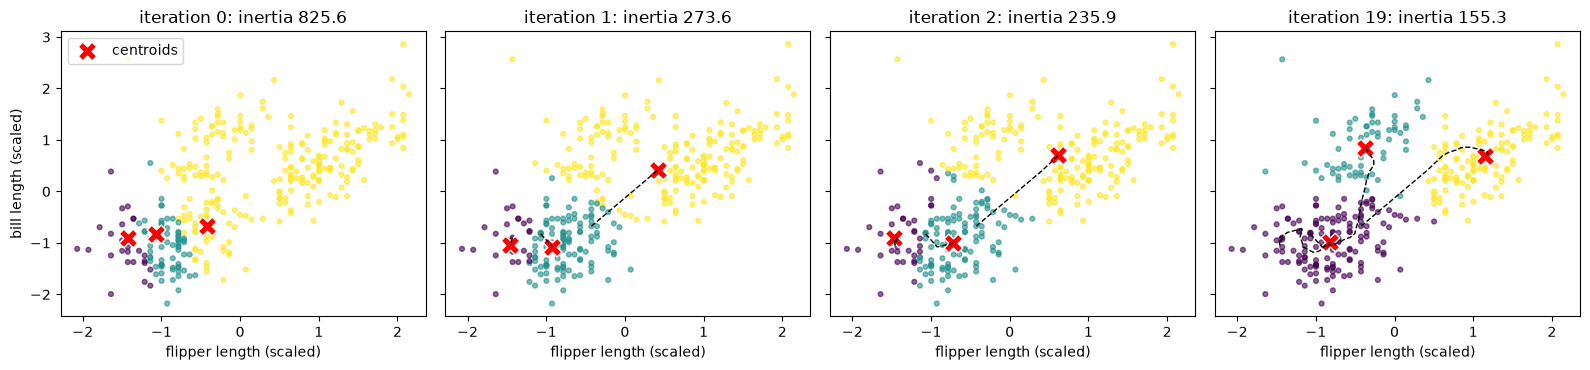

In [6]:
show = [0, 1, 2, len(frames) - 1]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharex=True, sharey=True)
path = np.array([f[0] for f in frames] + [centers])            # centroid positions over time
for ax, idx in zip(axes, show):
    c, lab = frames[idx]
    ax.scatter(X2[:, 0], X2[:, 1], c=lab, cmap="viridis", s=12, alpha=0.6)
    for j in range(3):
        ax.plot(path[: idx + 1, j, 0], path[: idx + 1, j, 1], "k--", lw=1)
    ax.scatter(c[:, 0], c[:, 1], c="red", marker="X", s=180, edgecolor="white", label="centroids")
    ax.set(title=f"iteration {idx}: inertia {((X2 - c[lab]) ** 2).sum():.1f}", xlabel="flipper length (scaled)")
axes[0].set_ylabel("bill length (scaled)")
axes[0].legend(loc="upper left")
plt.tight_layout()
plt.show()

The dashed lines trace the centroids. In the first frame all three start inside the Adelie group, so one centroid has to travel across the plot. After a few iterations the assignments stop changing.

### ✍️ Your Turn

Do **one update step** by hand in code: given `X_tiny` and its `labels_tiny`, compute the new centroid of each cluster (row 0 = cluster 0, row 1 = cluster 1). No loops needed for two clusters, but a list comprehension is fine.

In [7]:
X_tiny = np.array([[1.0, 2.0], [3.0, 4.0], [10.0, 10.0], [12.0, 14.0]])
labels_tiny = np.array([0, 0, 1, 1])
new_centroids = None  # TODO: your code here
check("new_centroids", new_centroids, [[2.0, 3.0], [11.0, 12.0]], hint="X_tiny[labels_tiny == j].mean(axis=0) for each j.")

⏳ new_centroids: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
X_tiny = np.array([[1.0, 2.0], [3.0, 4.0], [10.0, 10.0], [12.0, 14.0]])
labels_tiny = np.array([0, 0, 1, 1])
new_centroids = np.array([X_tiny[labels_tiny == j].mean(axis=0) for j in range(2)])
check("new_centroids", new_centroids, [[2.0, 3.0], [11.0, 12.0]])
```

The mean is the point that minimizes the squared distances to the cluster's members, which is why this step can never increase inertia.
</details>

> 💡 **Interview angle:** "Does K-Means always converge? To the global optimum?" — Yes, it always converges: both steps never increase inertia and there are finitely many partitions. No, not to the global optimum: it finds a local minimum, so use k-means++ and several restarts (`n_init`).

## 3. K-Means++ vs Random Initialization 🟡

**Random initialization** picks $k$ random data points as starting centroids. If two land in the same natural group, one real group gets no centroid and Lloyd's algorithm often can't recover.

**k-means++** (Arthur & Vassilvitskii, 2007) spreads the starting centroids out:

1. Pick the first centroid uniformly at random from the data.
2. For every point compute $D(x)$, the distance to the **nearest centroid chosen so far**.
3. Pick the next centroid at random with probability **proportional to $D(x)^2$**. Far-away points are much more likely to be picked.
4. Repeat until there are $k$ centroids, then run Lloyd's algorithm.

The paper proves the *expected* inertia right after seeding is within a factor $O(\log k)$ of the optimum. scikit-learn uses a **greedy** variant: at each step it samples `2 + int(log k)` candidates and keeps the one that lowers inertia most.

| `KMeans` argument | Default | Meaning |
|---|---|---|
| `init` | `"k-means++"` | also `"random"` or an array of starting centroids |
| `n_init` | `"auto"` | number of full restarts, best inertia wins: `"auto"` = 1 run for k-means++, 10 runs for random |
| `max_iter`, `tol` | 300, 1e-4 | stop after this many iterations or when centroids barely move |
| `algorithm` | `"lloyd"` | `"elkan"` uses the triangle inequality to skip distance computations |

Let's **measure** it on the handwritten digits (64 features, k = 10): 40 runs with each initialization, one restart each.

In [8]:
digits = load_digits()
X_digits, y_digits = digits.data, digits.target
n_runs = 40
init_rows = []
for seed in range(n_runs):
    start_centers = X_digits[np.random.default_rng(seed).choice(len(X_digits), 10, replace=False)]
    pp_centers, _ = kmeans_plusplus(X_digits, n_clusters=10, random_state=seed)
    for name, init_centers in [("random", start_centers), ("k-means++", pp_centers)]:
        seed_inertia = ((X_digits[:, None, :] - init_centers[None]) ** 2).sum(axis=2).min(axis=1).sum()
        start = time.perf_counter()
        km = KMeans(n_clusters=10, init=init_centers, n_init=1, random_state=seed).fit(X_digits)
        init_rows.append({"init": name, "seed": seed, "inertia at start": seed_inertia, "final inertia": km.inertia_,
                          "iterations": km.n_iter_, "ARI vs digit": adjusted_rand_score(y_digits, km.labels_),
                          "fit ms": (time.perf_counter() - start) * 1000})
init_df = pd.DataFrame(init_rows)
best_ever = init_df["final inertia"].min()
init_df["within 0.5% of best"] = init_df["final inertia"] <= best_ever * 1.005
summary = init_df.groupby("init").agg(
    start_inertia=("inertia at start", "mean"), final_mean=("final inertia", "mean"), final_std=("final inertia", "std"),
    final_worst=("final inertia", "max"), iterations=("iterations", "mean"), ari=("ARI vs digit", "mean"),
    near_best=("within 0.5% of best", "mean"))
print(summary.round(1).to_string())

           start_inertia  final_mean  final_std  final_worst  iterations  ari  near_best
init                                                                                    
k-means++      1.980e+06   1.179e+06    16011.7    1.219e+06        20.7  0.6        0.5
random         2.286e+06   1.188e+06    27149.3    1.270e+06        20.0  0.6        0.5


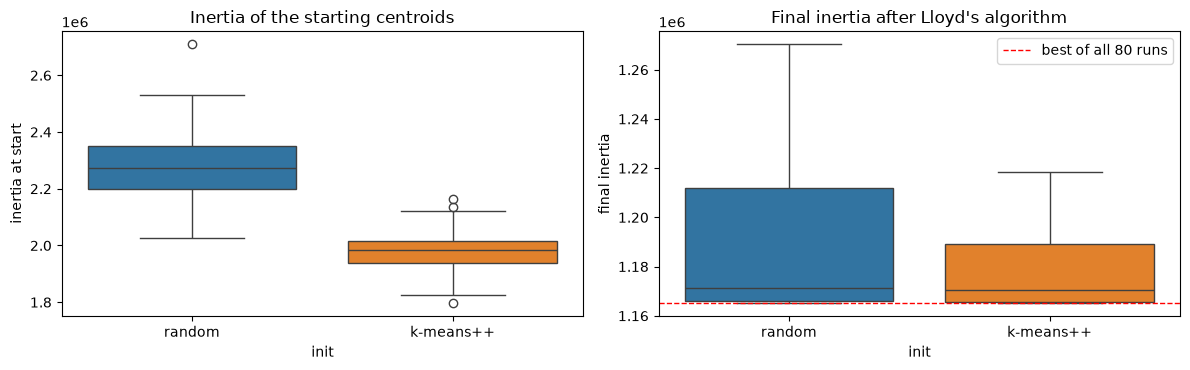

k-means++ starting centroids have 1.15× lower inertia; Lloyd then needs 0.7 more iterations on average (20.7 vs 20.0).
Spread of final inertia (std): k-means++ 16012 vs random 27149.
Final inertia: k-means++ mean 1178946 (worst 1218629) vs random mean 1187659 (worst 1270355).
→ Lower average final inertia: k-means++. Neither init reaches the best solution every time (near-best rate: k-means++ 50%, random 48%) → keep n_init > 1 when it matters.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
sns.boxplot(data=init_df, x="init", y="inertia at start", hue="init", ax=axes[0], legend=False)
axes[0].set_title("Inertia of the starting centroids")
sns.boxplot(data=init_df, x="init", y="final inertia", hue="init", ax=axes[1], legend=False)
axes[1].axhline(best_ever, color="red", ls="--", lw=1, label="best of all 80 runs")
axes[1].set_title("Final inertia after Lloyd's algorithm")
axes[1].legend()
plt.tight_layout()
plt.show()

pp, rnd = summary.loc["k-means++"], summary.loc["random"]
iter_diff = pp["iterations"] - rnd["iterations"]
print(f"k-means++ starting centroids have {rnd['start_inertia'] / pp['start_inertia']:.2f}× lower inertia; Lloyd then needs "
      f"{abs(iter_diff):.1f} {'more' if iter_diff > 0 else 'fewer'} iterations on average ({pp['iterations']:.1f} vs {rnd['iterations']:.1f}).")
print(f"Spread of final inertia (std): k-means++ {pp['final_std']:.0f} vs random {rnd['final_std']:.0f}.")
print(f"Final inertia: k-means++ mean {pp['final_mean']:.0f} (worst {pp['final_worst']:.0f}) vs random mean "
      f"{rnd['final_mean']:.0f} (worst {rnd['final_worst']:.0f}).")
better = "k-means++" if pp["final_mean"] < rnd["final_mean"] else "random"
print(f"→ Lower average final inertia: {better}. Neither init reaches the best solution every time "
      f"(near-best rate: k-means++ {pp['near_best']:.0%}, random {rnd['near_best']:.0%}) → keep n_init > 1 when it matters.")

**Reading the result:** compare the *starting* inertia, the *average* final inertia and especially the *worst* run. The main practical gain of k-means++ is **consistency**: fewer disastrous starts, so a single run is usually good enough. It still lands in different local minima on different seeds, which is why restarts (`n_init`) remain useful when the result matters. On data with many well-separated groups the difference is larger, because random starts more often put two centroids in one group.

### ✍️ Your Turn

Compute the k-means++ **selection probabilities** for the next centroid. The data are the 1-D points `[0, 1, 5]` and the first centroid is at `0`. (Probability ∝ squared distance to the nearest chosen centroid.)

In [10]:
points_1d = np.array([0.0, 1.0, 5.0])
first_centroid = 0.0
pick_prob = None  # TODO: your code here
check("pick_prob", pick_prob, [0.0, 1 / 26, 25 / 26], hint="d2 = (points_1d - first_centroid) ** 2; then d2 / d2.sum().")

⏳ pick_prob: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
points_1d = np.array([0.0, 1.0, 5.0])
first_centroid = 0.0
d2 = (points_1d - first_centroid) ** 2
pick_prob = d2 / d2.sum()
check("pick_prob", pick_prob, [0.0, 1 / 26, 25 / 26])
```

The point at 5 is picked 25 times more often than the point at 1. A point that already is a centroid has probability 0, so it is never picked twice.
</details>

> 💡 **Interview angle:** "What problem does k-means++ solve?" — bad random starts that put two centroids in one real cluster and leave another uncovered. It samples each new centroid with probability ∝ $D(x)^2$, which gives an $O(\log k)$ approximation in expectation, faster convergence, and more consistent results. Mention `n_init` restarts as the complement.

## 4. Choosing k: Elbow, Silhouette, and Gap Statistic 🟡

K-Means needs $k$ up front, and inertia **always** decreases as $k$ grows (with $k = n$ it is 0). So "lowest inertia" can't choose $k$. Three common tools:

**1. Elbow method.** Plot inertia against $k$ and look for the bend where adding a cluster stops helping much. Simple, but the bend is often vague. We find it automatically as the point farthest from the straight line joining the first and last points of the curve.

**2. Silhouette score.** For each point $i$:
- $a(i)$ = mean distance to the **other points in its own cluster** (how tight its cluster is),
- $b(i)$ = mean distance to the points of the **nearest other cluster** (how far the next group is),

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}} \in [-1, 1]$$

Near 1: well inside its cluster. Near 0: on a border. Negative: probably in the wrong cluster. Pick the $k$ with the highest **mean** silhouette, and look at the per-point silhouette plot. It costs $O(n^2)$, so use `sample_size=` on big data.

**3. Gap statistic** (Tibshirani, Walther & Hastie, 2001). Compare $\log W_k$ (log inertia) with what you'd get on **structureless** data of the same range, drawn uniformly at random $B$ times:

$$\text{Gap}(k) = \frac{1}{B}\sum_{b=1}^{B} \log W_k^{*(b)} - \log W_k$$

Choose the **smallest $k$** with $\text{Gap}(k) \ge \text{Gap}(k+1) - s_{k+1}$, where $s_{k+1}$ is the simulation standard deviation times $\sqrt{1 + 1/B}$. Unlike silhouette, it can say "$k = 1$: there are no clusters".

In [11]:
def elbow_k(ks, inertias):
    """Knee = point with the largest distance to the straight line joining the first and last points (normalized axes)."""
    x = (np.asarray(ks) - ks[0]) / (ks[-1] - ks[0])
    y = (np.asarray(inertias) - inertias[-1]) / (inertias[0] - inertias[-1])
    return int(ks[np.argmax(np.abs(1 - x - y))])     # distance to the line y = 1 - x (up to a constant factor)


def gap_statistic(X, ks, n_refs=20, seed=SEED):
    """Tibshirani's gap statistic with uniform reference data drawn in the bounding box of X."""
    gen = np.random.default_rng(seed)
    lo, hi = X.min(axis=0), X.max(axis=0)
    gaps, sks = [], []
    for k in ks:
        log_wk = np.log(KMeans(n_clusters=k, n_init=3, random_state=seed).fit(X).inertia_)
        ref_logs = [np.log(KMeans(n_clusters=k, n_init=3, random_state=seed).fit(gen.uniform(lo, hi, size=X.shape)).inertia_)
                    for _ in range(n_refs)]
        gaps.append(np.mean(ref_logs) - log_wk)
        sks.append(np.std(ref_logs) * np.sqrt(1 + 1 / n_refs))
    gaps, sks = np.array(gaps), np.array(sks)
    chosen = next((ks[i] for i in range(len(ks) - 1) if gaps[i] >= gaps[i + 1] - sks[i + 1]), ks[-1])
    return gaps, sks, chosen


ks = list(range(1, 10))
k_rows = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=5, random_state=SEED).fit(X_peng_s)
    row = {"k": k, "inertia": km.inertia_}
    if k > 1:
        row.update({"silhouette": silhouette_score(X_peng_s, km.labels_),
                    "Calinski-Harabasz": calinski_harabasz_score(X_peng_s, km.labels_),
                    "Davies-Bouldin": davies_bouldin_score(X_peng_s, km.labels_),
                    "ARI vs species (hidden)": adjusted_rand_score(species, km.labels_)})
    k_rows.append(row)
k_table = pd.DataFrame(k_rows).set_index("k")
gaps, gap_sd, k_gap = gap_statistic(X_peng_s, ks)
k_table["gap"] = gaps
print(k_table.round(3).to_string())

k_votes = {"elbow": elbow_k(ks, k_table["inertia"].to_numpy()),
           "silhouette (max)": int(k_table["silhouette"].idxmax()),
           "Calinski-Harabasz (max)": int(k_table["Calinski-Harabasz"].idxmax()),
           "Davies-Bouldin (min)": int(k_table["Davies-Bouldin"].idxmin()),
           "gap statistic": k_gap}
print("\nk chosen by each method:", k_votes)
print(f"(for reference only, the hidden species give the best ARI at k={int(k_table['ARI vs species (hidden)'].idxmax())})")

    inertia  silhouette  Calinski-Harabasz  Davies-Bouldin  ARI vs species (hidden)    gap
k                                                                                         
1  1332.000         NaN                NaN             NaN                      NaN  0.527
2   552.671       0.531            466.748           0.715                    0.649  1.128
3   370.766       0.446            427.773           0.942                    0.799  1.363
4   294.028       0.399            387.144           0.945                    0.646  1.420
5   228.508       0.374            395.989           0.979                    0.572  1.573
6   200.419       0.369            369.254           0.956                    0.554  1.605
7   183.171       0.327            340.774           1.085                    0.472  1.602
8   167.139       0.299            323.579           1.141                    0.412  1.584
9   155.286       0.288            306.898           1.202                    0.354  1.591

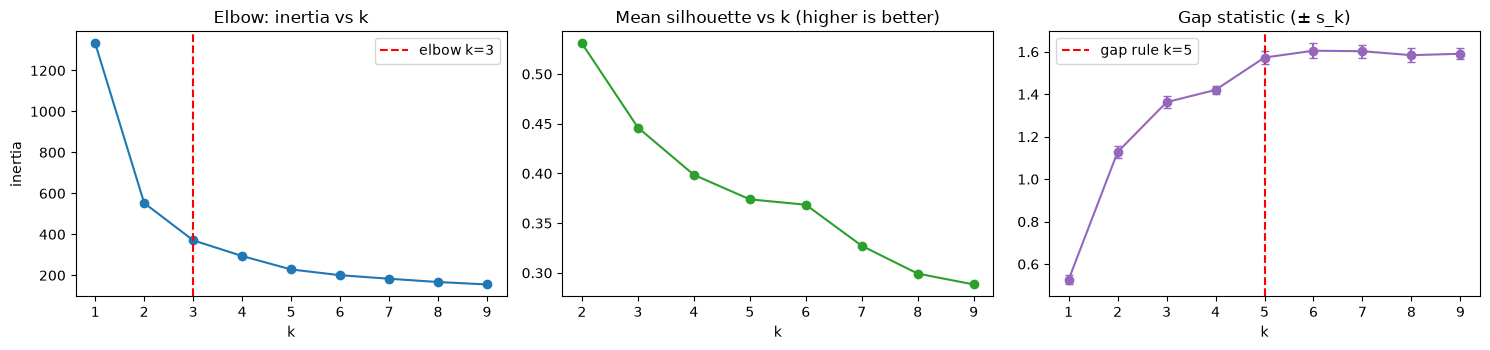

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].plot(ks, k_table["inertia"], "o-")
axes[0].axvline(k_votes["elbow"], color="red", ls="--", label=f"elbow k={k_votes['elbow']}")
axes[0].set(title="Elbow: inertia vs k", xlabel="k", ylabel="inertia")
axes[1].plot(ks[1:], k_table["silhouette"].dropna(), "o-", color="tab:green")
axes[1].set(title="Mean silhouette vs k (higher is better)", xlabel="k")
axes[2].errorbar(ks, gaps, yerr=gap_sd, fmt="o-", color="tab:purple", capsize=3)
axes[2].axvline(k_gap, color="red", ls="--", label=f"gap rule k={k_gap}")
axes[2].set(title="Gap statistic (± s_k)", xlabel="k")
for ax in (axes[0], axes[2]):
    ax.legend()
plt.tight_layout()
plt.show()

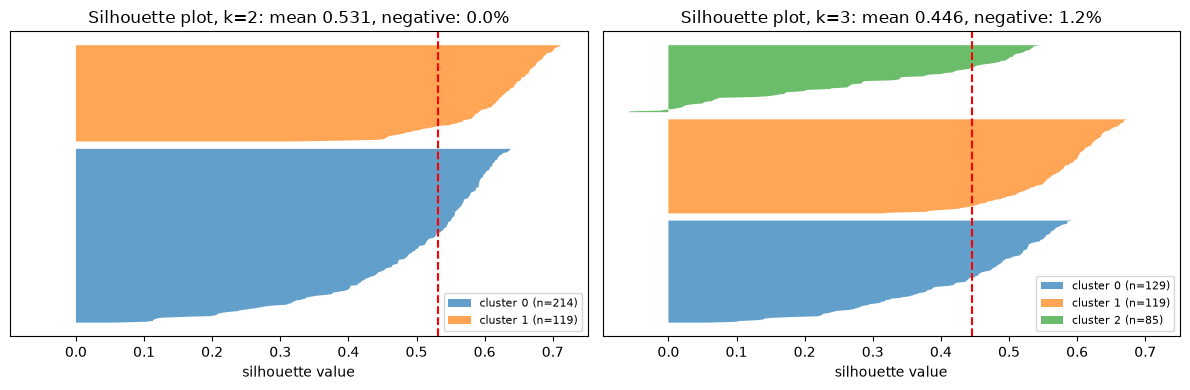

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for ax, k in zip(axes, [2, 3]):
    lab = KMeans(n_clusters=k, n_init=5, random_state=SEED).fit_predict(X_peng_s)
    sil = silhouette_samples(X_peng_s, lab)
    y_low = 0
    for j in range(k):
        vals = np.sort(sil[lab == j])
        ax.fill_betweenx(np.arange(y_low, y_low + len(vals)), 0, vals, alpha=0.7, label=f"cluster {j} (n={len(vals)})")
        y_low += len(vals) + 8
    ax.axvline(sil.mean(), color="red", ls="--")
    ax.set(title=f"Silhouette plot, k={k}: mean {sil.mean():.3f}, negative: {(sil < 0).mean():.1%}",
           xlabel="silhouette value", yticks=[])
    ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

**How to read this:** the methods don't have to agree, and they often don't. Silhouette rewards the cleanest separation (Gentoo vs the rest). The species question needs a finer split. In practice, shortlist 2–3 values of $k$ with these tools, then decide with **stability** and whether the clusters are **useful** (the mini project does exactly this).

### ✍️ Your Turn

Compute the silhouette value of the point at `0.0` by hand. Clusters: A = `[0.0, 1.0]`, B = `[4.0, 6.0]` (1-D). Use the formula, then confirm it matches `silhouette_samples`.

In [14]:
a_i = None  # TODO: mean distance from 0.0 to the other points in A
b_i = None  # TODO: mean distance from 0.0 to the points in B
sil_point = None  # TODO: (b - a) / max(a, b)
check("sil_point", sil_point, 0.8, hint="a = |0-1| = 1; b = mean(|0-4|, |0-6|) = 5.")

⏳ sil_point: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
a_i = abs(0.0 - 1.0)
b_i = np.mean([abs(0.0 - 4.0), abs(0.0 - 6.0)])
sil_point = (b_i - a_i) / max(a_i, b_i)
check("sil_point", sil_point, 0.8)
check("matches sklearn", silhouette_samples(np.array([[0.0], [1.0], [4.0], [6.0]]), [0, 0, 1, 1])[0], 0.8)
```
</details>

> 💡 **Interview angle:** "How do you choose k in K-Means?" — never by minimum inertia (it always falls). Use the elbow as a rough guide, the silhouette (mean and per-point plot), the gap statistic or Calinski–Harabasz, then check stability across resamples and whether the business can act on the clusters. Say out loud that different criteria can pick different k.

## 5. Scaling Matters 🟢

K-Means uses squared Euclidean distance: $\lVert x - y \rVert^2 = \sum_j (x_j - y_j)^2$. Every feature adds its squared difference. A feature measured in **grams** (differences of ~1,000) adds about a million, and a feature measured in **millimetres** (differences of ~5) adds about 25. So without scaling, K-Means effectively clusters on the large-unit feature alone.

| Scaler | What it does | Good for |
|---|---|---|
| `StandardScaler` | mean 0, standard deviation 1 | the default choice |
| `MinMaxScaler` | squeeze into [0, 1] | bounded features, no big outliers |
| `RobustScaler` | subtract median, divide by IQR | features with outliers |

For right-skewed amounts (money, counts), apply `np.log1p` **before** scaling. The mini project shows why.

In [15]:
raw_std = pd.Series(X_peng.std(axis=0), index=PENGUIN_FEATURES)
var_share = raw_std**2 / (raw_std**2).sum()
print(pd.DataFrame({"std (raw units)": raw_std.round(2), "share of total variance": var_share.map("{:.3%}".format)}))

scaling_rows, scaling_labels = [], {}
for name, scaler in [("no scaling", None), ("StandardScaler", StandardScaler()),
                     ("MinMaxScaler", MinMaxScaler()), ("RobustScaler", RobustScaler())]:
    kmeans = KMeans(n_clusters=3, n_init=10, random_state=SEED)
    model = kmeans if scaler is None else make_pipeline(scaler, kmeans)     # the scaler lives inside the pipeline
    lab = model.fit_predict(X_peng)
    scaling_labels[name] = lab
    scaling_rows.append({"preprocessing": name, "ARI vs species": adjusted_rand_score(species, lab),
                         "NMI vs species": normalized_mutual_info_score(species, lab),
                         "cluster sizes": sorted(np.bincount(lab).tolist(), reverse=True)})
scaling_table = pd.DataFrame(scaling_rows).set_index("preprocessing")
print("\n", scaling_table.round(3))

raw_centroids = pd.DataFrame(KMeans(n_clusters=3, n_init=10, random_state=SEED).fit(X_peng).cluster_centers_,
                             columns=PENGUIN_FEATURES)
print("\nUnscaled K-Means centroids (original units):\n", raw_centroids.round(1))

                   std (raw units) share of total variance
bill_length_mm                5.46                  0.005%
bill_depth_mm                 1.97                  0.001%
flipper_length_mm            13.99                  0.030%
body_mass_g                 804.01                 99.965%

                 ARI vs species  NMI vs species   cluster sizes
preprocessing                                                 
no scaling               0.321           0.403  [161, 102, 70]
StandardScaler           0.799           0.790  [129, 119, 85]
MinMaxScaler             0.739           0.743  [125, 119, 89]
RobustScaler             0.787           0.775  [131, 119, 83]

Unscaled K-Means centroids (original units):
    bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0            44.9           16.9              204.7       4445.3
1            41.3           18.0              190.1       3522.0
2            48.9           15.5              220.6       5435.4


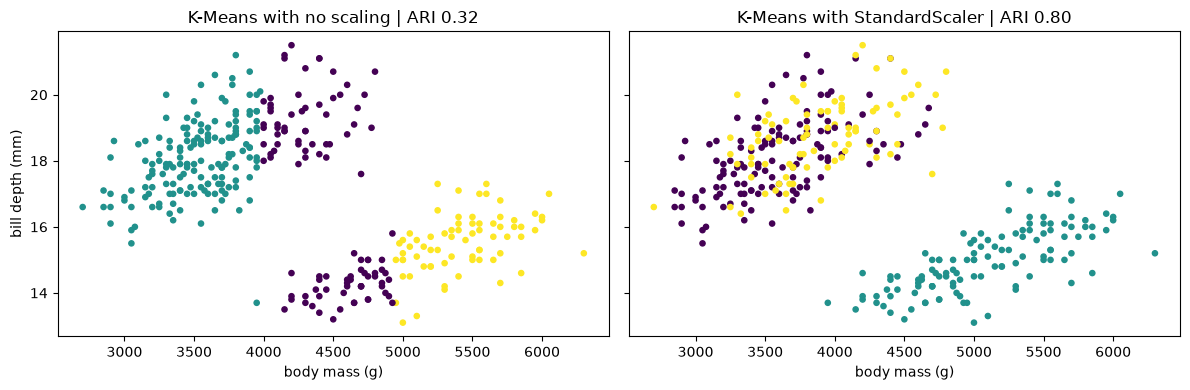

Without scaling, body_mass_g holds 99.96% of the total variance: the centroids differ by 1913 g in mass but only 2.5 mm in bill depth, so the clusters are just body-mass bands (the left plot has vertical stripes).
StandardScaler changes the ARI vs species by +0.478.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, name in zip(axes, ["no scaling", "StandardScaler"]):
    ax.scatter(penguins["body_mass_g"], penguins["bill_depth_mm"], c=scaling_labels[name], cmap="viridis", s=14)
    ax.set(title=f"K-Means with {name} | ARI {scaling_table.loc[name, 'ARI vs species']:.2f}",
           xlabel="body mass (g)")
axes[0].set_ylabel("bill depth (mm)")
plt.tight_layout()
plt.show()

gain = scaling_table.loc["StandardScaler", "ARI vs species"] - scaling_table.loc["no scaling", "ARI vs species"]
mass_spread = raw_centroids["body_mass_g"].max() - raw_centroids["body_mass_g"].min()
bill_spread = raw_centroids["bill_depth_mm"].max() - raw_centroids["bill_depth_mm"].min()
print(f"Without scaling, body_mass_g holds {var_share['body_mass_g']:.2%} of the total variance: the centroids differ by "
      f"{mass_spread:.0f} g in mass but only {bill_spread:.1f} mm in bill depth, so the clusters are just body-mass bands "
      "(the left plot has vertical stripes).")
print(f"StandardScaler changes the ARI vs species by {gain:+.3f}.")

### ✍️ Your Turn

Build a pipeline that scales with `StandardScaler` and clusters with `KMeans(n_clusters=3, n_init=10, random_state=SEED)`, then call `fit_predict` on the **raw** `X_peng`. Store the labels in `scaled_labels`.

In [17]:
scaled_labels = None  # TODO: your code here
check("scaling beats raw", None if scaled_labels is None else
      bool(adjusted_rand_score(species, scaled_labels) > scaling_table.loc["no scaling", "ARI vs species"] + 0.2), True,
      hint="make_pipeline(StandardScaler(), KMeans(...)).fit_predict(X_peng)")

⏳ scaling beats raw: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
scaled_labels = make_pipeline(StandardScaler(), KMeans(n_clusters=3, n_init=10, random_state=SEED)).fit_predict(X_peng)
check("scaling beats raw", bool(adjusted_rand_score(species, scaled_labels) > scaling_table.loc["no scaling", "ARI vs species"] + 0.2), True)
```

Putting the scaler **inside** the pipeline means `predict` on new penguins reuses the same means and standard deviations automatically.
</details>

> 💡 **Interview angle:** "Why must you scale before K-Means?" — it minimizes squared Euclidean distance, so features with large numeric ranges dominate. Standardize (or log-transform then standardize for skewed amounts), and put the scaler in a `Pipeline` so new data gets the same transform. Trees don't need this; distance-based methods do.

## 6. Assumptions and Failure Modes 🟡

K-Means has hidden assumptions. It works best when clusters are:

1. **Round (spherical) and convex.** Each point goes to the nearest centroid, so the boundary between two clusters is a **straight line halfway between their centroids** (a *Voronoi* partition). Curved or elongated shapes get cut wrongly.
2. **Similar in spread and size.** The halfway boundary ignores that one cluster may be wide and another tight. A big, wide cluster loses its edge points to a small neighbour.
3. **Free of noise.** Every point must join some cluster, so outliers drag centroids.
4. **In a space where Euclidean distance means something** (scaled numeric features).

(In the next notebook you'll see that K-Means is a special case of a Gaussian mixture where every cluster has the *same round* shape.)

To *see* each failure clearly we use **synthetic 2-D datasets on purpose**. The true groups are known, so ARI measures exactly how wrong each method is. We compare K-Means with Ward linkage and single linkage (Section 8 explains linkages).

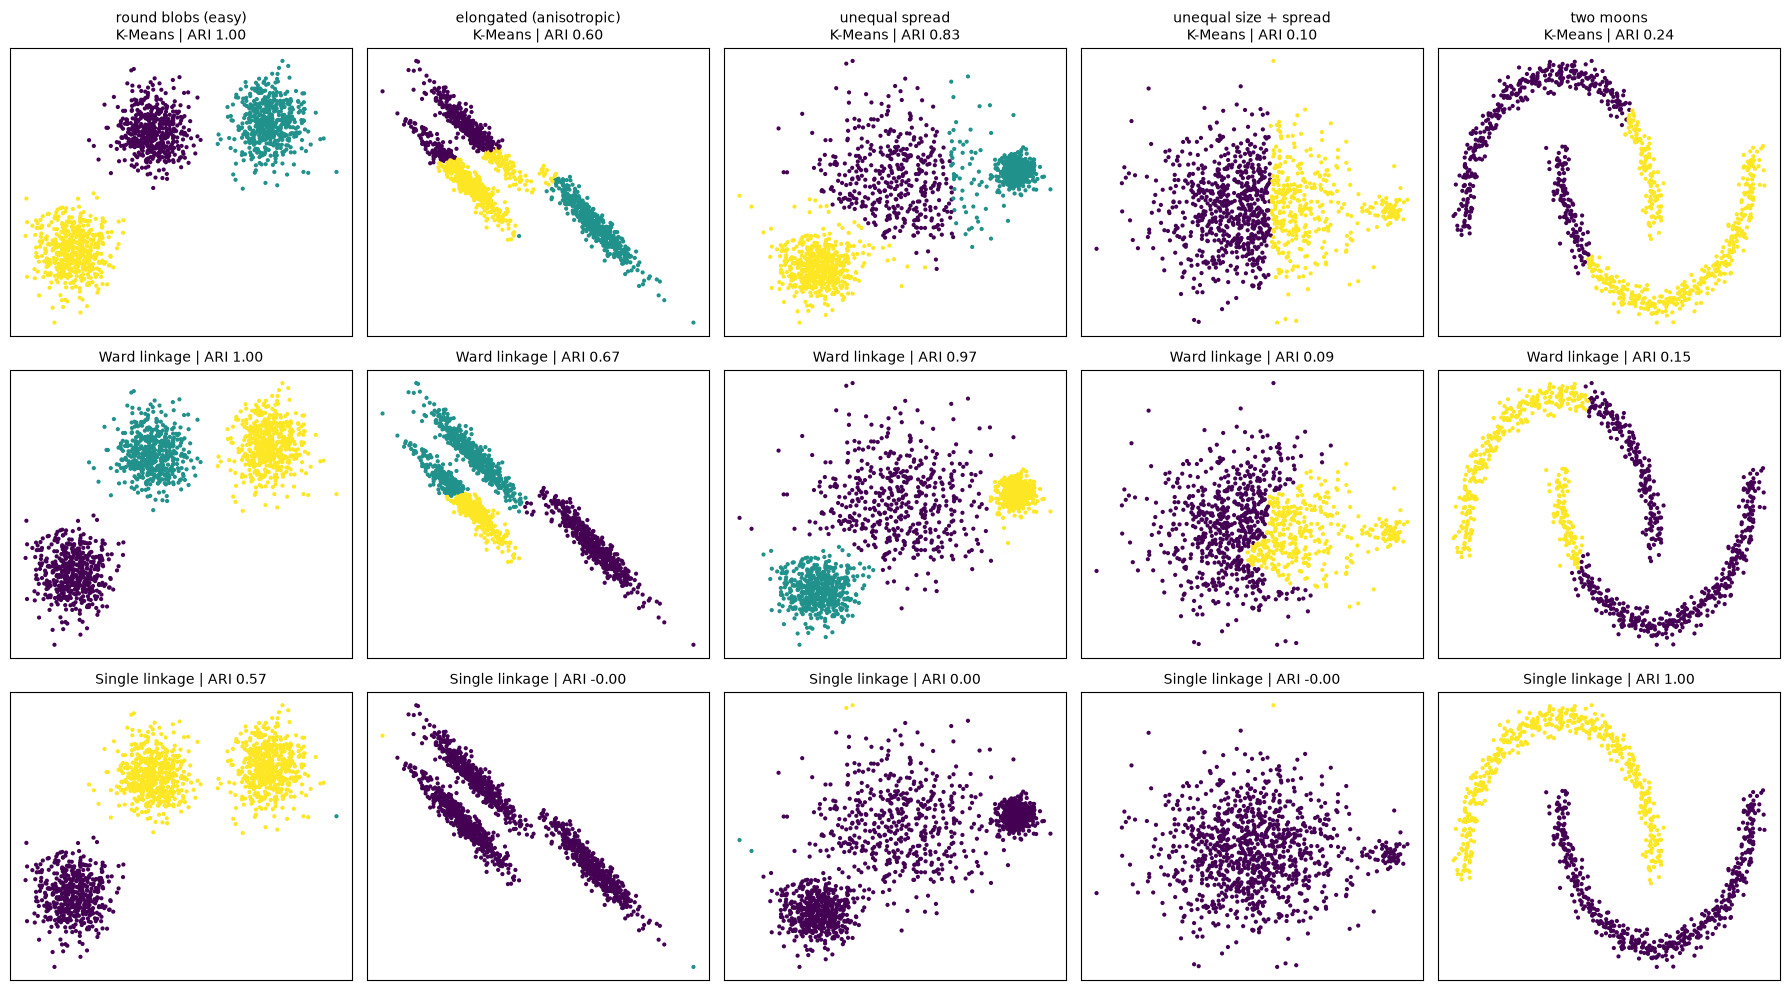

                         K-Means  Ward linkage  Single linkage
round blobs (easy)         1.000         1.000           0.571
elongated (anisotropic)    0.599         0.671          -0.000
unequal spread             0.826         0.966           0.000
unequal size + spread      0.099         0.095          -0.002
two moons                  0.239         0.150           1.000
- round blobs (easy)       K-Means ARI 1.00 (fine); best here: K-Means (1.00)
- elongated (anisotropic)  K-Means ARI 0.60 (FAILS); best here: Ward linkage (0.67)
- unequal spread           K-Means ARI 0.83 (FAILS); best here: Ward linkage (0.97)
- unequal size + spread    K-Means ARI 0.10 (FAILS); best here: K-Means (0.10)
- two moons                K-Means ARI 0.24 (FAILS); best here: Single linkage (1.00)


In [18]:
X_base, y_base = make_blobs(n_samples=1500, random_state=170)
failure_sets = {
    "round blobs (easy)": (X_base, y_base),
    "elongated (anisotropic)": (X_base @ np.array([[0.60, -0.64], [-0.41, 0.85]]), y_base),
    "unequal spread": make_blobs(n_samples=1500, cluster_std=[1.0, 2.5, 0.5], random_state=170),
    "unequal size + spread": make_blobs(n_samples=[1000, 60], centers=[[0.0, 0.0], [4.5, 0.0]],
                                        cluster_std=[1.5, 0.3], random_state=SEED),
    "two moons": make_moons(n_samples=1000, noise=0.05, random_state=SEED),
}
failure_algos = {
    "K-Means": lambda k: KMeans(n_clusters=k, n_init=10, random_state=SEED),
    "Ward linkage": lambda k: AgglomerativeClustering(n_clusters=k, linkage="ward"),
    "Single linkage": lambda k: AgglomerativeClustering(n_clusters=k, linkage="single"),
}
fail_ari = pd.DataFrame(index=list(failure_sets), columns=list(failure_algos), dtype=float)
fail_labels = {}
fig, axes = plt.subplots(len(failure_algos), len(failure_sets), figsize=(18, 10))
for col, (ds_name, (Xf, yf)) in enumerate(failure_sets.items()):
    k = len(np.unique(yf))
    for row, (algo_name, make_model) in enumerate(failure_algos.items()):
        lab = make_model(k).fit_predict(Xf)
        fail_labels[(ds_name, algo_name)] = lab
        fail_ari.loc[ds_name, algo_name] = adjusted_rand_score(yf, lab)
        ax = axes[row, col]
        ax.scatter(Xf[:, 0], Xf[:, 1], c=lab, cmap="viridis", s=4)
        ax.set_xticks([])
        ax.set_yticks([])
        title = f"{algo_name} | ARI {fail_ari.loc[ds_name, algo_name]:.2f}"
        ax.set_title(f"{ds_name}\n{title}" if row == 0 else title, fontsize=10)
plt.tight_layout()
plt.show()

print(fail_ari.round(3))
for ds_name, row in fail_ari.iterrows():
    verdict = "fine" if row["K-Means"] >= 0.9 else "FAILS"
    print(f"- {ds_name:24s} K-Means ARI {row['K-Means']:.2f} ({verdict}); best here: {row.idxmax()} ({row.max():.2f})")

**What happened:**
- **Round blobs:** everything works; this is K-Means' home ground.
- **Elongated / unequal spread / unequal size:** K-Means draws straight halfway boundaries, so points at the edge of a wide cluster get assigned to the neighbour. Ward linkage also minimizes squared error, so it shares this bias (compare its ARI on the unequal-size set), although its bottom-up merging copes better on some sets.
- **Two moons:** single linkage follows the chain of close neighbours along each moon and recovers them. K-Means and Ward cut the moons in half.
- Single linkage is not a universal fix: it breaks as soon as clusters touch (look at its ARI on the blob datasets).

The same issue happens on real data. Adelie and Chinstrap penguins overlap in these measurements and the two species have very different sizes, so K-Means (k=3) mixes them:

In [19]:
species_crosstab = pd.crosstab(pd.Series(species, name="species"), pd.Series(labels_k3, name="K-Means cluster (k=3)"))
print(species_crosstab)
purity = (species_crosstab.max(axis=1) / species_crosstab.sum(axis=1)).sort_values()
most_split = purity.index[0]
outside = species_crosstab.loc[most_split].drop(species_crosstab.loc[most_split].idxmax())
dest_cluster = outside.idxmax()
dest_owner = species_crosstab[dest_cluster].idxmax()
print(f"\nShare of each species inside its main cluster: {purity.round(3).to_dict()}")
print(f"→ The most split species is {most_split} ({(species == most_split).sum()} birds): {outside.max()} of them sit in "
      f"cluster {dest_cluster}, which is dominated by {dest_owner} ({(species == dest_owner).sum()} birds). "
      "The straight halfway boundary cuts through the overlap between the two groups.")

K-Means cluster (k=3)    0    1   2
species                            
Adelie                 124    0  22
Chinstrap                5    0  63
Gentoo                   0  119   0

Share of each species inside its main cluster: {'Adelie': 0.849, 'Chinstrap': 0.926, 'Gentoo': 1.0}
→ The most split species is Adelie (146 birds): 22 of them sit in cluster 2, which is dominated by Chinstrap (68 birds). The straight halfway boundary cuts through the overlap between the two groups.


> 💡 **Interview angle:** "When does K-Means fail, and what would you use instead?" — non-convex shapes (moons, rings) → DBSCAN/HDBSCAN or single linkage; elongated or different-size/spread clusters → Gaussian mixtures with full covariance; lots of noise → HDBSCAN; unscaled features → scale first. Explain the root cause: straight Voronoi boundaries halfway between centroids.

## 7. MiniBatchKMeans for Large Data 🟡

Full K-Means touches **every row in every iteration**. **Mini-batch K-Means** (Sculley, 2010) learns from small random batches instead:

1. Draw a random batch of $b$ rows (e.g. 4,096).
2. Assign each batch row to its nearest centroid.
3. Move each centroid a small step towards its batch rows: $\mu_j \leftarrow \mu_j + \eta_j\,(x - \mu_j)$ with a **per-centroid learning rate** $\eta_j = 1 / (\text{number of points centroid } j \text{ has absorbed so far})$. This keeps each centroid equal to the running average of everything it has seen.
4. Stop when the smoothed batch inertia stops improving (`max_no_improvement`).

The cost per step is $O(b\,k\,d)$ **no matter how large $n$ is**, and `partial_fit` lets you feed data chunk by chunk, so the full dataset never has to fit in memory. The price is a slightly worse (higher) inertia.

Let's measure it on a real, larger dataset: **581,012 forest patches** with 10 numeric map features (elevation, slope, distances to water/roads, hillshade), using $k = 64$ (e.g. building a 64-code "vocabulary" of terrain types).

In [20]:
covtype = fetch_covtype()
perm_cov = rng.permutation(len(covtype.data))
X_cov = StandardScaler().fit_transform(covtype.data[perm_cov, :10])      # the 10 numeric columns, shuffled
del covtype
gc.collect()
print(f"forest cover data: {X_cov.shape[0]:,} rows × {X_cov.shape[1]} features ({X_cov.nbytes / 1e6:.0f} MB)")

K_BIG = 64
mb_rows = []
for n in [50_000, 200_000, len(X_cov)]:
    X_n = X_cov[:n]
    start = time.perf_counter()
    full_km = KMeans(n_clusters=K_BIG, n_init=1, random_state=SEED).fit(X_n)
    full_s = time.perf_counter() - start
    start = time.perf_counter()
    mini_km = MiniBatchKMeans(n_clusters=K_BIG, batch_size=4096, n_init=1, random_state=SEED).fit(X_n)
    mini_s = time.perf_counter() - start
    mb_rows.append({"rows": n, "KMeans seconds": full_s, "MiniBatch seconds": mini_s, "speed-up ×": full_s / mini_s,
                    "inertia gap %": 100 * (-mini_km.score(X_n) / full_km.inertia_ - 1),
                    "label agreement (ARI)": adjusted_rand_score(full_km.labels_, mini_km.predict(X_n))})
mb_table = pd.DataFrame(mb_rows).set_index("rows")
print(mb_table.round(3))

forest cover data: 581,012 rows × 10 features (46 MB)


        KMeans seconds  MiniBatch seconds  speed-up ×  inertia gap %  label agreement (ARI)
rows                                                                                       
50000            0.177              0.075       2.380          4.003                  0.408
200000           0.371              0.221       1.682          3.097                  0.389
581012           3.854              0.902       4.271          3.513                  0.423


partial_fit over 20 chunks (one pass): 0.04s | inertia +5.49% vs full KMeans | peak data in memory per step: 29,050 rows instead of 581,012


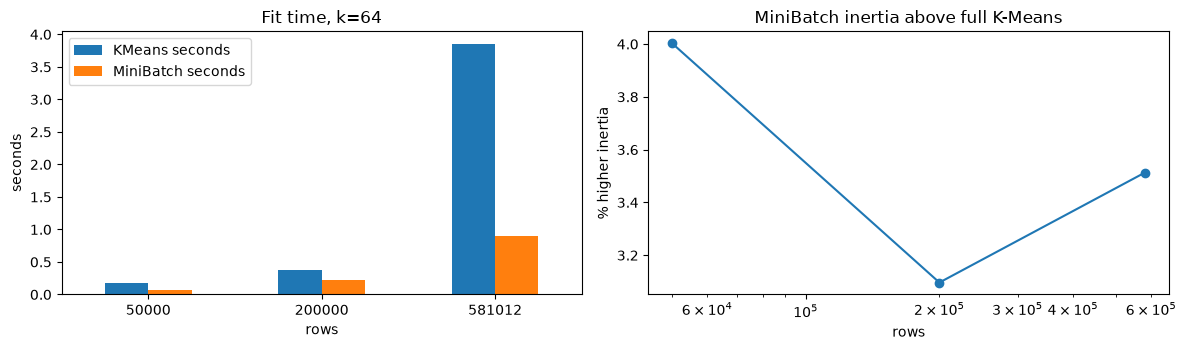

At 581,012 rows, MiniBatchKMeans was 4.3× faster with 3.5% higher inertia.
→ The speed-up grows with n while the quality cost stays a few percent: use MiniBatch for big data or streams.


In [21]:
stream_km = MiniBatchKMeans(n_clusters=K_BIG, n_init=1, random_state=SEED)
start = time.perf_counter()
for chunk in np.array_split(X_cov, 20):          # pretend each chunk arrives from disk or a message queue
    stream_km.partial_fit(chunk)
stream_s = time.perf_counter() - start
stream_gap = 100 * (-stream_km.score(X_cov) / full_km.inertia_ - 1)
print(f"partial_fit over 20 chunks (one pass): {stream_s:.2f}s | inertia {stream_gap:+.2f}% vs full KMeans "
      f"| peak data in memory per step: {len(X_cov) // 20:,} rows instead of {len(X_cov):,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
mb_table[["KMeans seconds", "MiniBatch seconds"]].plot(kind="bar", ax=axes[0], rot=0)
axes[0].set(title=f"Fit time, k={K_BIG}", xlabel="rows", ylabel="seconds")
axes[1].plot(mb_table.index, mb_table["inertia gap %"], "o-")
axes[1].set(title="MiniBatch inertia above full K-Means", xlabel="rows", ylabel="% higher inertia", xscale="log")
plt.tight_layout()
plt.show()

biggest = mb_table.iloc[-1]
print(f"At {mb_table.index[-1]:,} rows, MiniBatchKMeans was {biggest['speed-up ×']:.1f}× "
      f"{'faster' if biggest['speed-up ×'] > 1 else 'slower'} with {biggest['inertia gap %']:.1f}% higher inertia.")
print("→ " + ("The speed-up grows with n while the quality cost stays a few percent: use MiniBatch for big data or streams."
              if mb_table["speed-up ×"].iloc[-1] > mb_table["speed-up ×"].iloc[0]
              else "Here the speed-up did not grow with n; full KMeans is already fast at this size, so prefer it unless memory or streaming forces mini-batches."))

X_cov_sample = X_cov[:20_000].copy()             # kept for a pitfall later
del X_cov, X_n, full_km, mini_km, stream_km
_ = gc.collect()

**Takeaways:** scikit-learn's full `KMeans` is already heavily optimized (multi-threaded, vectorized), so on small data it can be as fast as mini-batches. The mini-batch advantage is largest with many rows and large $k$, and `partial_fit` is the only option when the data doesn't fit in memory. Check the quality cost on your data: compare inertia on a sample.

Also look at the **label agreement** column: the two partitions can differ a lot even when their inertia is within a few percent. With 64 clusters on data that has no clear natural groups, many different partitions are almost equally good. That's fine for compression, but a warning sign if you plan to *interpret* individual clusters.

### ✍️ Your Turn

Do one mini-batch **centroid update** by hand. A centroid at `[0, 0]` has absorbed `3` points so far. One new batch point `[4, 8]` is assigned to it. Update the count, compute $\eta = 1/\text{count}$, and move the centroid.

In [22]:
centroid = np.array([0.0, 0.0])
count = 3
x_new = np.array([4.0, 8.0])
updated_centroid = None  # TODO: your code here
check("updated_centroid", updated_centroid, [1.0, 2.0], hint="count becomes 4, eta = 1/4, centroid + eta * (x_new - centroid).")

⏳ updated_centroid: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
centroid = np.array([0.0, 0.0])
count = 3
x_new = np.array([4.0, 8.0])
count += 1
eta = 1 / count
updated_centroid = centroid + eta * (x_new - centroid)
check("updated_centroid", updated_centroid, [1.0, 2.0])
```

If the 3 earlier points averaged to `[0, 0]`, the average of all 4 points is exactly `[1, 2]`: the $1/\text{count}$ rate makes the centroid a running mean.
</details>

> 💡 **Interview angle:** "How would you cluster 500 million rows?" — MiniBatchKMeans with `partial_fit` over chunks (or Spark MLlib / FAISS k-means on GPU), k-means++ on a sample for initialization, and validate inertia/silhouette on a sample. Per-step cost is $O(bkd)$, independent of $n$; the trade-off is a few percent higher inertia.

## 8. Hierarchical Agglomerative Clustering and Linkages 🟡

**Agglomerative** ("gathering together") clustering builds clusters bottom-up:

1. Start with every point as its own cluster ($n$ clusters).
2. Find the **two closest clusters** and merge them. Record the distance at which they merged (the **merge height**).
3. Repeat until one cluster remains. The record of merges is a tree: the **dendrogram**.

Distance between *points* is clear, but what is the distance between two *clusters* $A$ and $B$? That choice is the **linkage**:

| Linkage | Cluster distance | Behaviour |
|---|---|---|
| **single** | $\min_{a \in A, b \in B} d(a, b)$ (closest pair) | follows chains of neighbours: finds curved shapes, but one noisy "bridge" merges two groups (**chaining**) |
| **complete** | $\max_{a \in A, b \in B} d(a, b)$ (farthest pair) | compact clusters of similar diameter; sensitive to outliers |
| **average** (UPGMA) | mean of all pairwise distances | a compromise between single and complete |
| **Ward** | increase in total within-cluster SSE: $\Delta(A,B) = \frac{|A||B|}{|A|+|B|}\lVert \mu_A - \mu_B \rVert^2$ | K-Means-like round, similar-size clusters; Euclidean distance only |

**Updating distances after a merge** doesn't require going back to the points. The **Lance–Williams formula** gives the distance from the merged cluster $A \cup B$ to any other cluster $C$ from the old distances. For example single linkage uses $\min(d(A,C), d(B,C))$ and complete linkage uses $\max(d(A,C), d(B,C))$.

**Cost:** the pairwise distances need $O(n^2)$ memory (20,000 rows → 200 million distances ≈ 1.6 GB as float64). A naive implementation is $O(n^3)$ time; good algorithms reach $O(n^2)$ for single, complete, average and Ward (Müllner, 2011). That is why hierarchical clustering is used on thousands of rows, not millions.

SciPy detail worth knowing: for Ward, `scipy.cluster.hierarchy.linkage` reports merge heights as $\sqrt{2\,\Delta(A,B)}$, so two single points merge at exactly their Euclidean distance.

Let's compare the four linkages on the scaled penguins.

                     ARI vs species  NMI vs species  silhouette   cluster sizes  fit ms
method                                                                                 
single linkage                0.651           0.760       0.467   [213, 119, 1]   0.696
complete linkage              0.943           0.919       0.452  [151, 119, 63]   0.777
average linkage               0.943           0.915       0.455  [149, 119, 65]   0.753
ward linkage                  0.913           0.899       0.452  [157, 119, 57]   0.756
K-Means (reference)           0.799           0.790       0.446  [129, 119, 85]     NaN


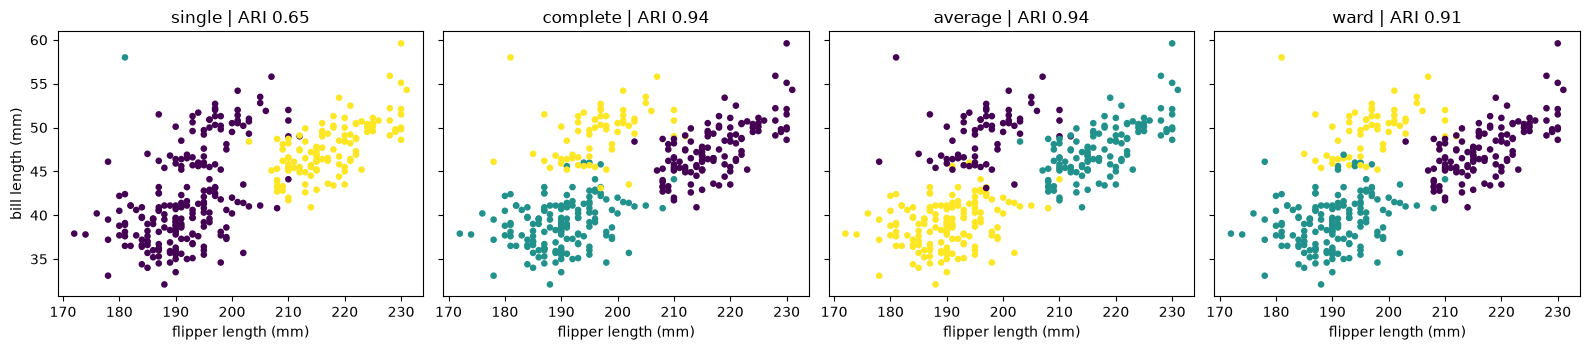

Best agreement with species: complete linkage (ARI 0.943).
Single linkage produced sizes [213, 119, 1]: its largest cluster holds 64% of the penguins and its smallest has 1 bird(s) → classic chaining: Adelie and Chinstrap touch, so they chain together.


In [23]:
linkage_rows, linkage_labels = [], {}
for method in ["single", "complete", "average", "ward"]:
    start = time.perf_counter()
    lab = AgglomerativeClustering(n_clusters=3, linkage=method).fit_predict(X_peng_s)
    fit_ms = (time.perf_counter() - start) * 1000
    linkage_labels[method] = lab
    linkage_rows.append({"method": f"{method} linkage", "ARI vs species": adjusted_rand_score(species, lab),
                         "NMI vs species": normalized_mutual_info_score(species, lab),
                         "silhouette": silhouette_score(X_peng_s, lab),
                         "cluster sizes": sorted(np.bincount(lab).tolist(), reverse=True), "fit ms": fit_ms})
linkage_rows.append({"method": "K-Means (reference)", "ARI vs species": adjusted_rand_score(species, labels_k3),
                     "NMI vs species": normalized_mutual_info_score(species, labels_k3),
                     "silhouette": silhouette_score(X_peng_s, labels_k3),
                     "cluster sizes": sorted(np.bincount(labels_k3).tolist(), reverse=True), "fit ms": np.nan})
linkage_table = pd.DataFrame(linkage_rows).set_index("method")
print(linkage_table.round(3))

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharex=True, sharey=True)
for ax, method in zip(axes, ["single", "complete", "average", "ward"]):
    ax.scatter(penguins["flipper_length_mm"], penguins["bill_length_mm"], c=linkage_labels[method], cmap="viridis", s=14)
    ax.set(title=f"{method} | ARI {linkage_table.loc[f'{method} linkage', 'ARI vs species']:.2f}", xlabel="flipper length (mm)")
axes[0].set_ylabel("bill length (mm)")
plt.tight_layout()
plt.show()

best_link = linkage_table["ARI vs species"].idxmax()
single_sizes = linkage_table.loc["single linkage", "cluster sizes"]
print(f"Best agreement with species: {best_link} (ARI {linkage_table.loc[best_link, 'ARI vs species']:.3f}).")
print(f"Single linkage produced sizes {single_sizes}: its largest cluster holds {single_sizes[0] / len(X_peng_s):.0%} "
      f"of the penguins and its smallest has {single_sizes[-1]} bird(s) → classic chaining: Adelie and Chinstrap touch, so they chain together.")

### ✍️ Your Turn

Compute the **single**, **complete** and **average** linkage distances between the two small clusters `A` and `B` (Euclidean distance). Store them in the dictionary `link_d`.

In [24]:
A = np.array([[0.0, 0.0], [0.0, 1.0]])
B = np.array([[3.0, 0.0], [5.0, 0.0]])
link_d = None  # TODO: {"single": ..., "complete": ..., "average": ...}
check("link_d", link_d, {"single": 3.0, "complete": np.sqrt(26), "average": (3 + 5 + np.sqrt(10) + np.sqrt(26)) / 4},
      hint="All pairwise distances: np.linalg.norm(A[:, None, :] - B[None, :, :], axis=2); then min, max, mean.")

⏳ link_d: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
A = np.array([[0.0, 0.0], [0.0, 1.0]])
B = np.array([[3.0, 0.0], [5.0, 0.0]])
pairwise = np.linalg.norm(A[:, None, :] - B[None, :, :], axis=2)   # shape (2, 2)
link_d = {"single": pairwise.min(), "complete": pairwise.max(), "average": pairwise.mean()}
check("link_d", link_d, {"single": 3.0, "complete": np.sqrt(26), "average": (3 + 5 + np.sqrt(10) + np.sqrt(26)) / 4})
```
</details>

> 💡 **Interview angle:** "Single vs complete vs average vs Ward linkage?" — single = closest pair (finds chains/curved shapes, suffers chaining; equivalent to cutting a minimum spanning tree), complete = farthest pair (compact, outlier-sensitive), average = mean pair (compromise), Ward = smallest increase in within-cluster variance (K-Means-like, Euclidean only, usually the best default for blob-like data).

## 9. Dendrograms, Cutting the Tree, and Connectivity 🟡

**The linkage matrix.** `scipy.cluster.hierarchy.linkage` returns an $(n-1) \times 4$ array `Z`. Row $t$ says: *at step $t$, cluster `Z[t, 0]` and cluster `Z[t, 1]` merged at height `Z[t, 2]`, giving a cluster of `Z[t, 3]` points*. IDs below $n$ are original points; ID $n + t$ is the cluster created at step $t$.

**The dendrogram** draws those merges: the y-axis is the merge height. **Cutting** the tree with a horizontal line at height $h$ gives the clusters that exist just below $h$. A **long vertical gap** with no merges means well-separated clusters, so a cut inside the largest gap is a natural choice of $k$.

| Tool | How to cut |
|---|---|
| `fcluster(Z, t=k, criterion="maxclust")` | exactly $k$ clusters |
| `fcluster(Z, t=h, criterion="distance")` | cut at height $h$ |
| `AgglomerativeClustering(n_clusters=None, distance_threshold=h)` | the scikit-learn way |

**Cophenetic correlation** checks how faithfully a tree represents the data: correlate the original pairwise distances with the **cophenetic distances** (the height at which two points first end up in the same cluster). Closer to 1 is more faithful.

In [25]:
Z_ward = linkage(X_peng_s, method="ward")
print("first 4 rows of Z [cluster a, cluster b, height, size]:\n", Z_ward[:4].round(3))
print("last 4 rows of Z:\n", Z_ward[-4:].round(3))

n_peng = len(X_peng_s)
gap_by_k = {k: float(Z_ward[n_peng - k, 2] - Z_ward[n_peng - k - 1, 2]) for k in range(2, 11)}   # height gap you cut through to get k clusters
k_dendro = max(gap_by_k, key=gap_by_k.get)
cut_height = (Z_ward[n_peng - k_dendro, 2] + Z_ward[n_peng - k_dendro - 1, 2]) / 2
print(f"\nheight gap per k: { {k: round(v, 2) for k, v in gap_by_k.items()} }")
print(f"largest gap → k = {k_dendro}, cutting at height {cut_height:.2f}")

labels_maxclust = fcluster(Z_ward, t=3, criterion="maxclust")
labels_distance = fcluster(Z_ward, t=cut_height, criterion="distance")
sk_ward = AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(X_peng_s)
sk_thresh = AgglomerativeClustering(n_clusters=None, distance_threshold=cut_height, linkage="ward").fit(X_peng_s)
print(f"SciPy k=3 cut vs scikit-learn Ward k=3: ARI {adjusted_rand_score(labels_maxclust, sk_ward):.3f}")
print(f"SciPy distance cut gives {len(np.unique(labels_distance))} clusters; scikit-learn distance_threshold gives {sk_thresh.n_clusters_}")
assert len(np.unique(labels_distance)) == sk_thresh.n_clusters_

coph = {m: float(cophenet(linkage(X_peng_s, method=m), pdist(X_peng_s))[0]) for m in ["single", "complete", "average", "ward"]}
print("cophenetic correlation:", {m: round(c, 3) for m, c in coph.items()},
      f"→ most faithful tree: {max(coph, key=coph.get)}")

first 4 rows of Z [cluster a, cluster b, height, size]:
 [[2.20e+02 3.04e+02 1.09e-01 2.00e+00]
 [2.54e+02 3.05e+02 1.09e-01 2.00e+00]
 [3.10e+01 1.01e+02 1.26e-01 2.00e+00]
 [2.60e+02 2.95e+02 1.32e-01 2.00e+00]]
last 4 rows of Z:
 [[656.    658.     12.092 157.   ]
 [649.    659.     12.127 119.   ]
 [660.    661.     18.399 214.   ]
 [662.    663.     39.48  333.   ]]

height gap per k: {2: 21.08, 3: 6.27, 4: 0.03, 5: 5.67, 6: 0.17, 7: 0.22, 8: 1.2, 9: 0.09, 10: 0.39}
largest gap → k = 2, cutting at height 28.94
SciPy k=3 cut vs scikit-learn Ward k=3: ARI 1.000
SciPy distance cut gives 2 clusters; scikit-learn distance_threshold gives 2
cophenetic correlation: {'single': 0.812, 'complete': 0.827, 'average': 0.844, 'ward': 0.834} → most faithful tree: average


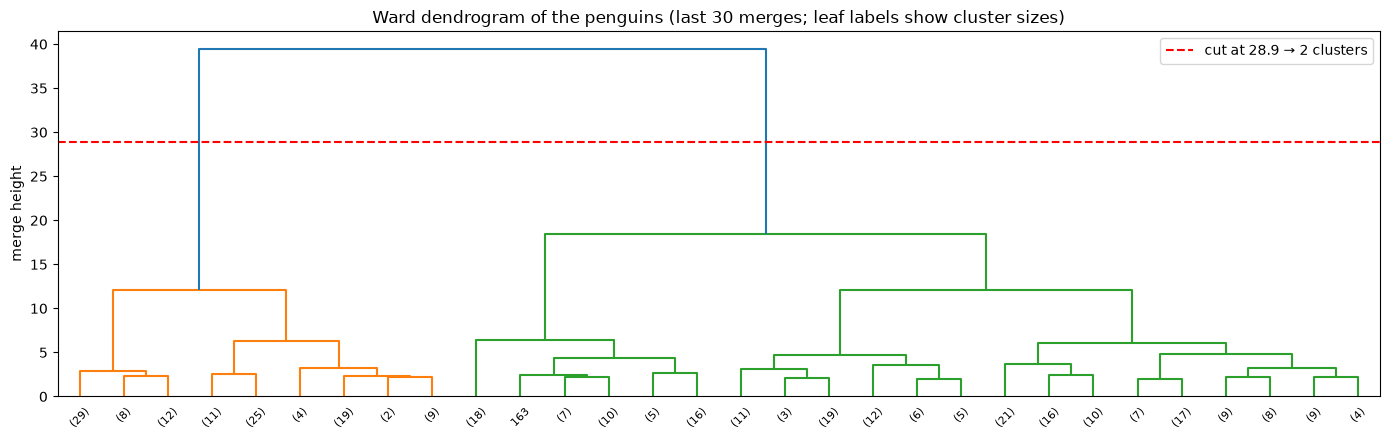

In [26]:
fig, ax = plt.subplots(figsize=(14, 4.5))
dendrogram(Z_ward, truncate_mode="lastp", p=30, color_threshold=cut_height, leaf_font_size=8, ax=ax)
ax.axhline(cut_height, color="red", ls="--", label=f"cut at {cut_height:.1f} → {k_dendro} clusters")
ax.set(title="Ward dendrogram of the penguins (last 30 merges; leaf labels show cluster sizes)", ylabel="merge height")
ax.legend()
plt.tight_layout()
plt.show()

### Connectivity constraints: clusters that must be neighbours

Sometimes clusters must be **contiguous**: sales territories, school districts or image segments can't be scattered pieces. A **connectivity matrix** (e.g. a $k$-nearest-neighbour graph on the coordinates) tells `AgglomerativeClustering` it may only merge clusters that touch. It also makes the algorithm faster, because far fewer merges are considered.

Real example: **3,000 California census districts**. We cluster on *housing features only* (log house value and log income), with and without a 10-nearest-neighbour graph on longitude/latitude, and measure **spatial coherence**: the share of each district's 10 nearest geographic neighbours that land in the same cluster.

                    spatial coherence  within-cluster SSE  fit ms                             cluster sizes
model                                                                                                      
no connectivity                 0.354             905.878  41.157  [742, 459, 455, 397, 325, 321, 160, 141]
10-NN connectivity              0.834            3247.136  51.152  [789, 704, 473, 324, 304, 189, 113, 104]


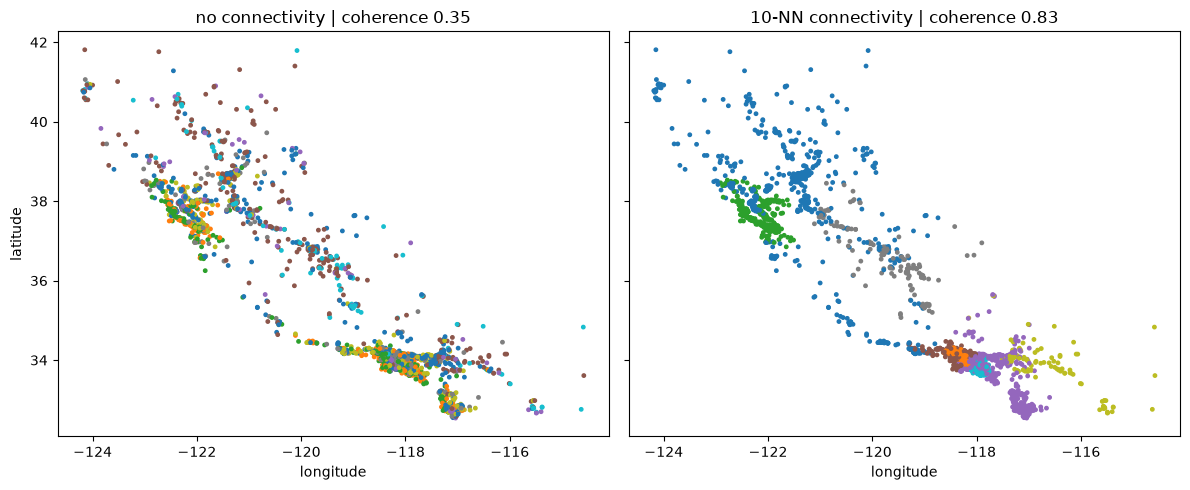

Connectivity raised spatial coherence from 0.35 to 0.83, at the cost of +258% within-cluster SSE (regions are less uniform in price), and fitting took 51 ms vs 41 ms.


In [27]:
housing = fetch_california_housing(as_frame=True).frame.sample(3000, random_state=SEED).reset_index(drop=True)
coords = housing[["Longitude", "Latitude"]].to_numpy()
house_features = StandardScaler().fit_transform(np.log(housing[["MedHouseVal", "MedInc"]]))
geo_neighbours = NearestNeighbors(n_neighbors=11).fit(coords).kneighbors(coords, return_distance=False)[:, 1:]
knn_graph = kneighbors_graph(coords, n_neighbors=10, include_self=False)

region_rows, region_labels = [], {}
for name, conn in [("no connectivity", None), ("10-NN connectivity", knn_graph)]:
    start = time.perf_counter()
    lab = AgglomerativeClustering(n_clusters=8, linkage="ward", connectivity=conn).fit_predict(house_features)
    fit_ms = (time.perf_counter() - start) * 1000
    region_labels[name] = lab
    sse = sum(((house_features[lab == j] - house_features[lab == j].mean(axis=0)) ** 2).sum() for j in np.unique(lab))
    region_rows.append({"model": name, "spatial coherence": (lab[geo_neighbours] == lab[:, None]).mean(),
                        "within-cluster SSE": sse, "fit ms": fit_ms,
                        "cluster sizes": sorted(np.bincount(lab).tolist(), reverse=True)})
region_table = pd.DataFrame(region_rows).set_index("model")
print(region_table.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, name in zip(axes, region_labels):
    ax.scatter(coords[:, 0], coords[:, 1], c=region_labels[name], cmap="tab10", s=6)
    ax.set(title=f"{name} | coherence {region_table.loc[name, 'spatial coherence']:.2f}", xlabel="longitude")
axes[0].set_ylabel("latitude")
plt.tight_layout()
plt.show()

r0, r1 = region_table.loc["no connectivity"], region_table.loc["10-NN connectivity"]
print(f"Connectivity raised spatial coherence from {r0['spatial coherence']:.2f} to {r1['spatial coherence']:.2f}, "
      f"at the cost of {100 * (r1['within-cluster SSE'] / r0['within-cluster SSE'] - 1):+.0f}% within-cluster SSE "
      f"(regions are less uniform in price), and fitting took {r1['fit ms']:.0f} ms vs {r0['fit ms']:.0f} ms.")

Without connectivity, "expensive coastal" districts from San Diego and San Francisco can share a cluster. With it, clusters become connected regions. You trade some within-cluster similarity for geography.

### ✍️ Your Turn

The 1-D points below are clustered with **single** linkage. Cut the tree at **height 3** with `fcluster(..., criterion="distance")` and store the **number of clusters** in `n_clusters_cut`.

In [28]:
pts_1d = np.array([[0.0], [1.0], [5.0], [6.0], [20.0]])
n_clusters_cut = None  # TODO: your code here
check("n_clusters_cut", n_clusters_cut, 3, hint="len(np.unique(fcluster(linkage(pts_1d, 'single'), t=3, criterion='distance')))")

⏳ n_clusters_cut: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
pts_1d = np.array([[0.0], [1.0], [5.0], [6.0], [20.0]])
Z_small = linkage(pts_1d, method="single")
print(Z_small)                                   # merges at heights 1, 1, 4, 14
n_clusters_cut = len(np.unique(fcluster(Z_small, t=3, criterion="distance")))
check("n_clusters_cut", n_clusters_cut, 3)
```

Merges at height 1 create {0, 1} and {5, 6}. The next merge is at height 4, above the cut, so {0, 1}, {5, 6} and {20} remain.
</details>

> 💡 **Interview angle:** "How do you pick the number of clusters from a dendrogram?" — cut through the longest vertical stretch without merges (the biggest jump in merge height), then confirm with silhouette/stability. Mention cophenetic correlation to check the tree represents the distances well, and connectivity constraints when clusters must be contiguous.

## 10. Internal vs External Evaluation Metrics 🟡

**Internal metrics** use only the data and the labels you found. **External metrics** compare with reference labels that you kept aside for checking.

| Metric | Type | Formula / idea | Range, best |
|---|---|---|---|
| **Silhouette** | internal | mean of $s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$ | −1…1, **higher** |
| **Davies–Bouldin (DB)** | internal | $\frac{1}{k}\sum_i \max_{j \ne i} \frac{s_i + s_j}{\lVert \mu_i - \mu_j \rVert}$, where $s_i$ = mean distance of cluster $i$'s points to its centroid | ≥ 0, **lower** |
| **Calinski–Harabasz (CH)** | internal | $\frac{\operatorname{tr}(B)/(k-1)}{\operatorname{tr}(W)/(n-k)}$: between-cluster scatter $B = \sum_j n_j \lVert\mu_j - \mu\rVert^2$ vs within-cluster scatter $W$ (= inertia) | ≥ 0, **higher** |
| **Rand index (RI)** | external | share of point **pairs** on which two labellings agree (same/different cluster) | 0…1, but random labels already score high |
| **Adjusted Rand index (ARI)** | external | $\frac{\text{RI} - \mathbb{E}[\text{RI}]}{\max \text{RI} - \mathbb{E}[\text{RI}]}$: corrected for chance | ≈ 0 random, 1 perfect (can be slightly negative) |
| **NMI** | external | mutual information $I(U;V)$ divided by the mean entropy $\tfrac12[H(U)+H(V)]$ | 0…1; grows with more clusters even for random labels |
| **AMI** | external | NMI corrected for chance | ≈ 0 random, 1 perfect |

**Two important caveats:**
1. Silhouette, DB and CH are built on centroids or distances, so they **favour round, convex clusters**. They can prefer a K-Means answer even when a different shape is the truth.
2. Internal metrics can't compare different preprocessing: scaling changes the distances themselves.

Let's score seven clusterings of the handwritten digits (k = 10), where the true digit is the external reference.

In [29]:
metric_models = {
    "K-Means": KMeans(n_clusters=10, n_init=10, random_state=SEED),
    "MiniBatchKMeans": MiniBatchKMeans(n_clusters=10, n_init=10, random_state=SEED),
    "BisectingKMeans": BisectingKMeans(n_clusters=10, n_init=5, random_state=SEED),
    "Ward": AgglomerativeClustering(n_clusters=10, linkage="ward"),
    "Complete": AgglomerativeClustering(n_clusters=10, linkage="complete"),
    "Average": AgglomerativeClustering(n_clusters=10, linkage="average"),
    "Single": AgglomerativeClustering(n_clusters=10, linkage="single"),
}
metric_rows, metric_labels = [], {}
for name, model in metric_models.items():
    lab = model.fit_predict(X_digits)
    metric_labels[name] = lab
    metric_rows.append({"algorithm": name, "silhouette ↑": silhouette_score(X_digits, lab),
                        "Davies-Bouldin ↓": davies_bouldin_score(X_digits, lab),
                        "Calinski-Harabasz ↑": calinski_harabasz_score(X_digits, lab),
                        "ARI ↑": adjusted_rand_score(y_digits, lab), "NMI ↑": normalized_mutual_info_score(y_digits, lab)})
metric_table = pd.DataFrame(metric_rows).set_index("algorithm")
print(metric_table.round(3))

rho, _ = spearmanr(metric_table["silhouette ↑"], metric_table["ARI ↑"])
print(f"\nBest by silhouette: {metric_table['silhouette ↑'].idxmax()} | by Davies-Bouldin: {metric_table['Davies-Bouldin ↓'].idxmin()} "
      f"| by Calinski-Harabasz: {metric_table['Calinski-Harabasz ↑'].idxmax()} | by ARI (truth): {metric_table['ARI ↑'].idxmax()}")
print(f"Spearman rank correlation between silhouette and ARI across the 7 algorithms: {rho:.2f}")
single_share = np.bincount(metric_labels["Single"]).max() / len(y_digits)
db_rank = int(metric_table["Davies-Bouldin ↓"].rank().loc["Single"])
print(f"Single linkage put {single_share:.1%} of all digits into one cluster (ARI {metric_table.loc['Single', 'ARI ↑']:.3f}), "
      f"yet Davies-Bouldin ranks it #{db_rank} of 7.")

                 silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑  ARI ↑  NMI ↑
algorithm                                                                         
K-Means                 0.182             1.921              169.340  0.667  0.739
MiniBatchKMeans         0.176             2.054              162.150  0.723  0.771
BisectingKMeans         0.167             2.017              158.158  0.627  0.702
Ward                    0.178             1.889              161.205  0.794  0.868
Complete                0.119             2.303              117.414  0.429  0.613
Average                 0.147             1.687              122.111  0.514  0.713
Single                 -0.134             0.924                1.246  0.000  0.010

Best by silhouette: K-Means | by Davies-Bouldin: Single | by Calinski-Harabasz: K-Means | by ARI (truth): Ward
Spearman rank correlation between silhouette and ARI across the 7 algorithms: 0.89
Single linkage put 99.5% of all digits into one cluster (A

Look at single linkage: it chains almost every digit into one giant cluster, leaving a few tiny ones. Davies–Bouldin only compares cluster spreads with centroid distances, so a giant cluster plus a few far-away tiny ones can look good to it. **Always read several metrics together**, and look at cluster sizes.

Now two traps with external metrics: **chance** and **number of clusters**.

In [30]:
random_10 = rng.integers(0, 10, len(y_digits))
random_100 = rng.integers(0, 100, len(y_digits))
chance_rows = []
for name, lab in [("random labels, 10 clusters", random_10), ("random labels, 100 clusters", random_100),
                  ("K-Means, 10 clusters", metric_labels["K-Means"])]:
    chance_rows.append({"labelling": name, "Rand index": rand_score(y_digits, lab), "ARI": adjusted_rand_score(y_digits, lab),
                        "NMI": normalized_mutual_info_score(y_digits, lab), "AMI": adjusted_mutual_info_score(y_digits, lab)})
chance_table = pd.DataFrame(chance_rows).set_index("labelling")
print(chance_table.round(3))
print(f"\n→ Random labels still get a Rand index of {chance_table.iloc[0]['Rand index']:.2f} (most pairs are 'different' in both), "
      f"but ARI {chance_table.iloc[0]['ARI']:+.3f}. With 100 random clusters NMI rises to {chance_table.iloc[1]['NMI']:.2f} "
      f"while AMI stays at {chance_table.iloc[1]['AMI']:+.3f} → prefer chance-adjusted ARI/AMI.")

                             Rand index    ARI    NMI    AMI
labelling                                                   
random labels, 10 clusters        0.821  0.002  0.013  0.003
random labels, 100 clusters       0.892 -0.000  0.082 -0.002
K-Means, 10 clusters              0.939  0.667  0.739  0.737

→ Random labels still get a Rand index of 0.82 (most pairs are 'different' in both), but ARI +0.002. With 100 random clusters NMI rises to 0.08 while AMI stays at -0.002 → prefer chance-adjusted ARI/AMI.


In [31]:
X_moons, y_moons = failure_sets["two moons"]
moon_rows = []
for algo in ["K-Means", "Single linkage"]:
    lab = fail_labels[("two moons", algo)]
    moon_rows.append({"algorithm": algo, "silhouette": silhouette_score(X_moons, lab),
                      "Davies-Bouldin": davies_bouldin_score(X_moons, lab), "ARI vs true moons": adjusted_rand_score(y_moons, lab)})
moon_table = pd.DataFrame(moon_rows).set_index("algorithm")
print(moon_table.round(3))
print(f"→ Silhouette prefers {moon_table['silhouette'].idxmax()}, but the true moons are recovered by "
      f"{moon_table['ARI vs true moons'].idxmax()}: internal metrics are biased towards round clusters.")

                silhouette  Davies-Bouldin  ARI vs true moons
algorithm                                                    
K-Means              0.489           0.784              0.239
Single linkage       0.334           1.156              1.000
→ Silhouette prefers K-Means, but the true moons are recovered by Single linkage: internal metrics are biased towards round clusters.


### ✍️ Your Turn

Compute the **Davies–Bouldin** index by hand for two 1-D clusters: A = `[0, 2]` and B = `[10, 12]`. Each $s_i$ is the mean distance of the cluster's points to its centroid. Then confirm with `davies_bouldin_score`.

In [32]:
s_A = None  # TODO: mean distance of 0 and 2 to their centroid
s_B = None  # TODO
db_by_hand = None  # TODO: (s_A + s_B) / distance between centroids   (with only 2 clusters, the max is that one pair)
check("db_by_hand", db_by_hand, 0.2, hint="Centroids 1 and 11; s_A = s_B = 1; distance 10.")

⏳ db_by_hand: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
s_A = np.mean(np.abs(np.array([0.0, 2.0]) - 1.0))
s_B = np.mean(np.abs(np.array([10.0, 12.0]) - 11.0))
db_by_hand = (s_A + s_B) / abs(11.0 - 1.0)
check("db_by_hand", db_by_hand, 0.2)
check("matches sklearn", davies_bouldin_score(np.array([[0.0], [2.0], [10.0], [12.0]]), [0, 0, 1, 1]), 0.2)
```
</details>

> 💡 **Interview angle:** "Silhouette vs ARI — when do you use which?" — silhouette (and DB, CH) need no labels and measure compactness/separation, but favour convex clusters. ARI/NMI need reference labels and measure agreement; ARI/AMI are adjusted for chance, NMI and the raw Rand index are not. Never compare cluster IDs to labels with accuracy.

## 11. Profiling and Interpreting Clusters 🟢

A clustering is only useful if people can **understand and act on it**. A standard profiling toolkit:

1. **Size**: how many rows per cluster (tiny clusters are often outliers).
2. **Profile in original units**: the mean or median of each feature per cluster.
3. **Standardized differences (z-scores)**: $(\text{cluster mean} - \text{overall mean}) / \text{overall std}$, to see what makes each cluster *different*.
4. **Crosstabs with variables you did not cluster on** (region, channel, species) to validate and enrich the story.
5. **A surrogate decision tree**: a shallow tree that predicts the cluster from the features, giving plain rules like "flipper > 206 mm → cluster 2". Its accuracy on held-out rows is its **fidelity**.
6. **Stability**: refit on bootstrap samples; if clusters change a lot, don't build a business process on them.

In [33]:
segment_model = make_pipeline(StandardScaler(), KMeans(n_clusters=3, n_init=10, random_state=SEED)).fit(X_peng)
peng_prof = penguins.assign(cluster=segment_model.predict(X_peng))

sizes = peng_prof["cluster"].value_counts().sort_index()
profile = peng_prof.groupby("cluster")[PENGUIN_FEATURES].mean()
overall_mean, overall_std = penguins[PENGUIN_FEATURES].mean(), penguins[PENGUIN_FEATURES].std(ddof=0)
z_profile = (profile - overall_mean) / overall_std
print("sizes:", sizes.to_dict())
print("\nmean profile (original units):\n", profile.round(1))


def describe_cluster(z_row, top=2):
    """Plain-English description from the largest standardized differences."""
    feats = z_row.abs().sort_values(ascending=False).index[:top]
    return ", ".join(f"{'high' if z_row[f] > 0 else 'low'} {f} ({z_row[f]:+.1f} SD)" for f in feats)


for c, z_row in z_profile.iterrows():
    print(f"cluster {c} (n={sizes[c]}): {describe_cluster(z_row)}")

sizes: {0: 129, 1: 119, 2: 85}

mean profile (original units):
          bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
cluster                                                               
0                  38.3           18.1              188.6       3593.8
1                  47.6           15.0              217.2       5092.4
2                  47.7           18.7              196.9       3898.2
cluster 0 (n=129): low bill_length_mm (-1.0 SD), low flipper_length_mm (-0.9 SD)
cluster 1 (n=119): high flipper_length_mm (+1.2 SD), low bill_depth_mm (-1.1 SD)
cluster 2 (n=85): high bill_depth_mm (+0.8 SD), high bill_length_mm (+0.7 SD)


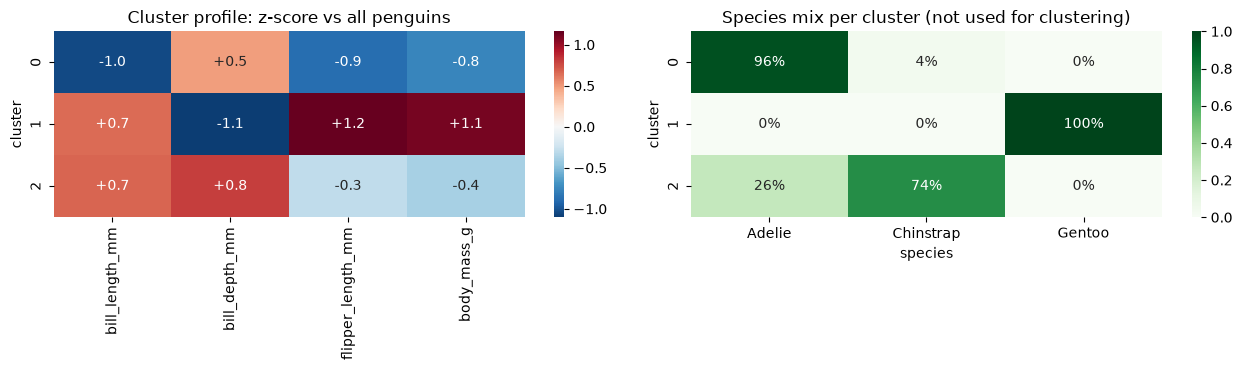

island mix per cluster:
 island   Biscoe  Dream  Torgersen
cluster                          
0          0.29   0.42       0.29
1          1.00   0.00       0.00
2          0.08   0.81       0.11


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
sns.heatmap(z_profile, annot=True, fmt="+.1f", cmap="RdBu_r", center=0, ax=axes[0])
axes[0].set_title("Cluster profile: z-score vs all penguins")
species_mix = pd.crosstab(peng_prof["cluster"], peng_prof["species"], normalize="index")
sns.heatmap(species_mix, annot=True, fmt=".0%", cmap="Greens", ax=axes[1])
axes[1].set_title("Species mix per cluster (not used for clustering)")
plt.tight_layout()
plt.show()
print("island mix per cluster:\n", pd.crosstab(peng_prof["cluster"], peng_prof["island"], normalize="index").round(2))

In [35]:
surrogate = DecisionTreeClassifier(max_depth=2, random_state=SEED)
fidelity = cross_val_score(surrogate, penguins[PENGUIN_FEATURES], peng_prof["cluster"], cv=5).mean()
surrogate.fit(penguins[PENGUIN_FEATURES], peng_prof["cluster"])
print(export_text(surrogate, feature_names=PENGUIN_FEATURES, decimals=1))
print(f"surrogate tree fidelity (5-fold CV accuracy at reproducing the clusters): {fidelity:.1%}")

reference = peng_prof["cluster"].to_numpy()
boot_ari = []
for b in range(30):
    idx = rng.integers(0, len(X_peng), len(X_peng))                     # bootstrap sample (with replacement)
    boot_model = make_pipeline(StandardScaler(), KMeans(n_clusters=3, n_init=10, random_state=b)).fit(X_peng[idx])
    boot_ari.append(adjusted_rand_score(reference, boot_model.predict(X_peng)))
boot_ari = np.array(boot_ari)
print(f"bootstrap stability over 30 refits: mean ARI {boot_ari.mean():.3f}, worst {boot_ari.min():.3f} → "
      + ("stable enough to use" if boot_ari.mean() >= 0.8 else "unstable: treat these clusters with caution"))

|--- flipper_length_mm <= 206.5
|   |--- bill_length_mm <= 41.7
|   |   |--- class: 0
|   |--- bill_length_mm >  41.7
|   |   |--- class: 2
|--- flipper_length_mm >  206.5
|   |--- bill_depth_mm <= 17.6
|   |   |--- class: 1
|   |--- bill_depth_mm >  17.6
|   |   |--- class: 2

surrogate tree fidelity (5-fold CV accuracy at reproducing the clusters): 94.0%


bootstrap stability over 30 refits: mean ARI 0.932, worst 0.802 → stable enough to use


### ✍️ Your Turn

Compute the **z-score profile** of `spend` for each cluster: (cluster mean − overall mean) / overall standard deviation, with the **population** standard deviation (`ddof=0`). Return a NumPy array ordered by cluster id.

In [36]:
tiny = pd.DataFrame({"spend": [10.0, 20.0, 30.0, 40.0], "cluster": [0, 0, 1, 1]})
z_spend = None  # TODO: your code here
check("z_spend", z_spend, [-0.894427, 0.894427], hint="(tiny.groupby('cluster')['spend'].mean() - mean) / tiny['spend'].std(ddof=0)")

⏳ z_spend: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
tiny = pd.DataFrame({"spend": [10.0, 20.0, 30.0, 40.0], "cluster": [0, 0, 1, 1]})
z_spend = ((tiny.groupby("cluster")["spend"].mean() - tiny["spend"].mean()) / tiny["spend"].std(ddof=0)).to_numpy()
check("z_spend", z_spend, [-0.894427, 0.894427])
```

Overall mean 25, population std ≈ 11.18; cluster means 15 and 35 are ∓0.89 standard deviations away.
</details>

> 💡 **Interview angle:** "You found 5 customer clusters — how do you explain them to the business?" — size and share, profiles in original units, z-score/index heatmap of what's different, crosstabs with known attributes, a shallow surrogate tree for simple rules, and a stability check. Give each segment a name and a suggested action, and state what you'd A/B test.

## 12. A Fair Head-to-Head Comparison 🔴

Is K-Means really the best choice, or would a neighbouring algorithm do better? A fair comparison needs the **same data splits, the same preprocessing and the same k** for every algorithm. There's no cross-validation for clustering, so we use the unsupervised analogue:

- **5 random subsamples** (80% of rows), with **identical row indices for every algorithm**.
- Each algorithm runs inside a `Pipeline` (scaling for penguins and wine; digit pixels already share one scale).
- We fit on the 80% and report **ARI vs the hidden labels**, **silhouette**, and **fit time**.
- We then **assign the other 20%** as "new rows": `predict` for the K-Means family, and the nearest cluster mean for agglomerative clustering, which has no `predict` (a tiny helper doing what `NearestCentroid` does). We report the ARI on those new rows and the prediction time.
- k is set to the true number of classes (3, 3, 10). This is fair to all algorithms, but it's a luxury you don't have in real projects.

In [37]:
wine = load_wine()
h2h_datasets = {"penguins": (X_peng, species, 3, True), "wine": (wine.data, wine.target, 3, True),
                "digits": (X_digits, y_digits, 10, False)}
h2h_algorithms = {
    "K-Means": lambda k: KMeans(n_clusters=k, n_init=10, random_state=SEED),
    "MiniBatchKMeans": lambda k: MiniBatchKMeans(n_clusters=k, n_init=10, batch_size=256, random_state=SEED),
    "BisectingKMeans": lambda k: BisectingKMeans(n_clusters=k, n_init=5, random_state=SEED),
    "Ward": lambda k: AgglomerativeClustering(n_clusters=k, linkage="ward"),
    "Average linkage": lambda k: AgglomerativeClustering(n_clusters=k, linkage="average"),
}
def assign_to_nearest_centroid(X_fit, fit_labels, X_new):
    """Label new rows with the nearest cluster mean (for models without predict)."""
    centroids = np.array([X_fit[fit_labels == c].mean(axis=0) for c in np.unique(fit_labels)])
    return np.unique(fit_labels)[((X_new[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2).argmin(axis=1)]


h2h_rows = []
for ds_name, (X_ds, y_ds, k, scale) in h2h_datasets.items():
    subsamples = [np.random.default_rng(SEED + r).permutation(len(X_ds)) for r in range(5)]   # shared by all algorithms
    for algo_name, make_model in h2h_algorithms.items():
        for r, perm in enumerate(subsamples):
            cut = int(0.8 * len(X_ds))
            fit_idx, new_idx = perm[:cut], perm[cut:]
            pipe = Pipeline([("scale", StandardScaler() if scale else "passthrough"), ("cluster", make_model(k))])
            start = time.perf_counter()
            fit_labels = pipe.fit_predict(X_ds[fit_idx])
            fit_ms = (time.perf_counter() - start) * 1000
            X_fit_t, X_new_t = pipe[:-1].transform(X_ds[fit_idx]), pipe[:-1].transform(X_ds[new_idx])
            start = time.perf_counter()
            if hasattr(pipe, "predict"):
                new_labels = pipe.predict(X_ds[new_idx])
            else:
                new_labels = assign_to_nearest_centroid(X_fit_t, fit_labels, X_new_t)
            predict_ms = (time.perf_counter() - start) * 1000
            h2h_rows.append({"dataset": ds_name, "algorithm": algo_name, "ARI (fit rows)": adjusted_rand_score(y_ds[fit_idx], fit_labels),
                             "ARI (new rows)": adjusted_rand_score(y_ds[new_idx], new_labels),
                             "silhouette": silhouette_score(X_fit_t, fit_labels), "fit ms": fit_ms, "predict ms": predict_ms})
h2h = pd.DataFrame(h2h_rows)
h2h_summary = h2h.groupby(["dataset", "algorithm"]).agg(
    ARI_mean=("ARI (fit rows)", "mean"), ARI_std=("ARI (fit rows)", "std"), ARI_new=("ARI (new rows)", "mean"),
    silhouette=("silhouette", "mean"), fit_ms=("fit ms", "mean"), predict_ms=("predict ms", "mean"))
print(h2h_summary.round(3).to_string())

                          ARI_mean  ARI_std  ARI_new  silhouette  fit_ms  predict_ms
dataset  algorithm                                                                  
digits   Average linkage     0.543    0.038    0.491       0.146  19.890       0.341
         BisectingKMeans     0.619    0.013    0.588       0.165  31.422       0.461
         K-Means             0.666    0.020    0.640       0.184  29.445       0.192
         MiniBatchKMeans     0.619    0.044    0.598       0.168  12.155       0.183
         Ward                0.778    0.010    0.692       0.178  21.467       0.354
penguins Average linkage     0.785    0.148    0.799       0.463   0.728       0.035
         BisectingKMeans     0.806    0.027    0.795       0.450   2.961       0.190
         K-Means             0.806    0.027    0.795       0.450   3.839       0.136
         MiniBatchKMeans     0.832    0.059    0.865       0.452   4.812       0.119
         Ward                0.936    0.015    0.933       0.453 

In [38]:
for ds_name in h2h_datasets:
    part = h2h_summary.loc[ds_name]
    best = part["ARI_mean"].idxmax()
    runner_up = part["ARI_mean"].drop(best).idxmax()
    margin = part.loc[best, "ARI_mean"] - part.loc[runner_up, "ARI_mean"]
    noise = part.loc[best, "ARI_std"] + part.loc[runner_up, "ARI_std"]
    print(f"{ds_name:8s}: best ARI {best} ({part.loc[best, 'ARI_mean']:.3f}) vs runner-up {runner_up} "
          f"({part.loc[runner_up, 'ARI_mean']:.3f}) → {'a clear win' if margin > noise else 'within run-to-run noise'}; "
          f"fastest fit: {part['fit_ms'].idxmin()} ({part['fit_ms'].min():.0f} ms); "
          f"new-row ARI of the best: {part.loc[best, 'ARI_new']:.3f}")

penguins: best ARI Ward (0.936) vs runner-up MiniBatchKMeans (0.832) → a clear win; fastest fit: Average linkage (1 ms); new-row ARI of the best: 0.933
wine    : best ARI K-Means (0.888) vs runner-up MiniBatchKMeans (0.880) → within run-to-run noise; fastest fit: Ward (1 ms); new-row ARI of the best: 0.920
digits  : best ARI Ward (0.778) vs runner-up K-Means (0.666) → a clear win; fastest fit: MiniBatchKMeans (12 ms); new-row ARI of the best: 0.692


**How to read it:** no algorithm wins everywhere, which is the honest answer interviewers want to hear. Choose on data size (hierarchical is quadratic), whether you need to assign new rows, the cluster shapes you expect, and **stability**, not on a third decimal. Notice that the new-row ARI is close to the fit-row ARI when the clusters generalize.

> 💡 **Interview angle:** "How would you compare clustering algorithms fairly?" — same preprocessing inside a pipeline, same subsamples/seeds, same k (or each method's own selection rule), several metrics (internal + external if a reference exists + stability), timing for fit and assignment of new points, and a conclusion that accounts for run-to-run variance.

## 🔧 Build It From Scratch

Two classic interview builds, each checked against the library.

### 1) K-Means with k-means++ initialization (NumPy only)

Given the **same starting centroids**, Lloyd's algorithm is deterministic, so our labels and inertia must match scikit-learn **exactly**. We pass `tol=0` so scikit-learn also stops only when no label changes, which is our rule.

In [39]:
def squared_distances(X, C):
    """(n, k) matrix of squared Euclidean distances, using ||x||² + ||c||² − 2·x·c."""
    return np.maximum((X**2).sum(axis=1)[:, None] + (C**2).sum(axis=1)[None, :] - 2 * X @ C.T, 0.0)


def kmeans_plus_plus_init(X, k, gen):
    """k-means++ seeding: next centroid sampled with probability ∝ D(x)²."""
    centers = [X[gen.integers(len(X))]]
    closest_sq = ((X - centers[0]) ** 2).sum(axis=1)
    for _ in range(1, k):
        idx = gen.choice(len(X), p=closest_sq / closest_sq.sum())
        centers.append(X[idx])
        closest_sq = np.minimum(closest_sq, ((X - X[idx]) ** 2).sum(axis=1))
    return np.array(centers)


class KMeansScratch:
    def __init__(self, n_clusters, max_iter=300, seed=0):
        self.n_clusters, self.max_iter, self.seed = n_clusters, max_iter, seed

    def fit(self, X, init=None):
        C = kmeans_plus_plus_init(X, self.n_clusters, np.random.default_rng(self.seed)) if init is None else init.copy()
        self.init_centers_ = C.copy()
        labels = None
        for self.n_iter_ in range(1, self.max_iter + 1):
            new_labels = squared_distances(X, C).argmin(axis=1)            # assignment step
            if labels is not None and np.array_equal(new_labels, labels):
                break                                                      # converged: no label changed
            labels = new_labels
            for j in range(self.n_clusters):                               # update step
                members = X[labels == j]
                if len(members):                                           # keep an empty cluster's old centroid
                    C[j] = members.mean(axis=0)
        self.cluster_centers_, self.labels_ = C, labels
        self.inertia_ = float(((X - C[labels]) ** 2).sum())
        return self

    def predict(self, X):
        return squared_distances(X, self.cluster_centers_).argmin(axis=1)


X_digits_s = StandardScaler().fit_transform(X_digits)
for data_name, X_check, k in [("digits (scaled)", X_digits_s, 10), ("penguins (scaled)", X_peng_s, 3)]:
    ours = KMeansScratch(n_clusters=k, seed=SEED).fit(X_check)
    sk = KMeans(n_clusters=k, init=ours.init_centers_, n_init=1, tol=0, algorithm="lloyd").fit(X_check)
    assert np.array_equal(ours.labels_, sk.labels_), "labels differ"
    assert np.isclose(ours.inertia_, sk.inertia_, rtol=1e-9), "inertia differs"
    assert np.array_equal(ours.predict(X_check[:50] + 0.01), sk.predict(X_check[:50] + 0.01))
    print(f"✅ {data_name}: identical labels, inertia {ours.inertia_:.4f} = {sk.inertia_:.4f}, predict matches")

ours_inertia = [KMeansScratch(10, seed=s).fit(X_digits_s).inertia_ for s in range(8)]
sk_inertia = [KMeans(10, n_init=1, random_state=s).fit(X_digits_s).inertia_ for s in range(8)]
ratio = np.mean(ours_inertia) / np.mean(sk_inertia)
print(f"our k-means++ vs scikit-learn's greedy k-means++ over 8 seeds: mean final inertia ratio {ratio:.4f}")
assert abs(ratio - 1) < 0.05

✅ digits (scaled): identical labels, inertia 70496.0811 = 70496.0811, predict matches
✅ penguins (scaled): identical labels, inertia 475.4428 = 475.4428, predict matches
our k-means++ vs scikit-learn's greedy k-means++ over 8 seeds: mean final inertia ratio 1.0147


### 2) Agglomerative clustering with single, complete and average linkage

A naive version: keep a cluster-to-cluster distance matrix, merge the closest pair, and update the merged row with the **Lance–Williams** rule (min for single, max for complete, size-weighted mean for average). This is $O(n^3)$, fine for 60 real penguins. We output a SciPy-style linkage matrix and assert that the **merge heights and the flat clusters** match `scipy.cluster.hierarchy.linkage`.

In [40]:
def agglomerative_scratch(X, method="complete"):
    n = len(X)
    D = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(axis=2))
    np.fill_diagonal(D, np.inf)
    active, ids, sizes = list(range(n)), list(range(n)), [1] * n
    Z = []
    for step in range(n - 1):
        sub = D[np.ix_(active, active)]
        pa, pb = np.unravel_index(np.argmin(sub), sub.shape)
        a, b = active[pa], active[pb]
        height = D[a, b]
        if method == "single":
            new_row = np.minimum(D[a], D[b])
        elif method == "complete":
            new_row = np.maximum(D[a], D[b])
        else:                                                  # average linkage (UPGMA)
            new_row = (sizes[a] * D[a] + sizes[b] * D[b]) / (sizes[a] + sizes[b])
        Z.append([min(ids[a], ids[b]), max(ids[a], ids[b]), height, sizes[a] + sizes[b]])
        D[a, :], D[:, a] = new_row, new_row                    # row a now represents the merged cluster
        D[a, a] = np.inf
        D[b, :], D[:, b] = np.inf, np.inf                      # cluster b no longer exists
        sizes[a] += sizes[b]
        ids[a] = n + step
        active.remove(b)
    return np.array(Z)


sample_rows = rng.choice(len(X_peng_s), 60, replace=False)
X_small = X_peng_s[sample_rows]
for method in ["single", "complete", "average"]:
    Z_ours, Z_scipy = agglomerative_scratch(X_small, method), linkage(X_small, method=method)
    assert np.allclose(Z_ours[:, 2], Z_scipy[:, 2]), f"{method}: merge heights differ"
    same_flat = adjusted_rand_score(fcluster(Z_ours, 3, "maxclust"), fcluster(Z_scipy, 3, "maxclust")) == 1.0
    assert same_flat, f"{method}: flat clusters differ"
    print(f"✅ {method:8s}: all {len(Z_ours)} merge heights match SciPy (last three: {Z_ours[-3:, 2].round(3)}) and the k=3 cut is identical")

✅ single  : all 59 merge heights match SciPy (last three: [0.929 1.451 1.861]) and the k=3 cut is identical
✅ complete: all 59 merge heights match SciPy (last three: [3.049 4.401 5.832]) and the k=3 cut is identical
✅ average : all 59 merge heights match SciPy (last three: [2.219 2.391 3.448]) and the k=3 cut is identical


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Comparing cluster IDs with labels using `==`

Cluster numbers are arbitrary names. Renaming clusters doesn't change the clustering, but it changes "accuracy" completely.

In [41]:
species_codes = pd.Series(species).map({"Adelie": 0, "Chinstrap": 1, "Gentoo": 2}).to_numpy()
renamed = (labels_k3 + 1) % 3                                   # the same clustering with different names
print(f"❌ 'accuracy' with the original names: {np.mean(labels_k3 == species_codes):.1%} | "
      f"after renaming: {np.mean(renamed == species_codes):.1%}")
cm = pd.crosstab(species_codes, labels_k3).to_numpy()
row_ind, col_ind = linear_sum_assignment(-cm)                   # best one-to-one matching of clusters to species
print(f"✅ ARI {adjusted_rand_score(species_codes, labels_k3):.3f} (renamed: {adjusted_rand_score(species_codes, renamed):.3f}) | "
      f"accuracy after optimal matching: {cm[row_ind, col_ind].sum() / cm.sum():.1%}")

❌ 'accuracy' with the original names: 37.2% | after renaming: 43.8%
✅ ARI 0.799 (renamed: 0.799) | accuracy after optimal matching: 91.9%


### ❌ Pitfall 2 — Choosing k by the lowest inertia

In [42]:
inertia_by_k = {k: KMeans(n_clusters=k, n_init=3, random_state=SEED).fit(X_peng_s).inertia_ for k in range(2, 16)}
print(f"❌ k with the lowest inertia: {min(inertia_by_k, key=inertia_by_k.get)} (inertia always falls as k grows)")
print(f"✅ k from silhouette: {k_votes['silhouette (max)']}, from the gap statistic: {k_votes['gap statistic']}, "
      f"from the elbow: {k_votes['elbow']} (Section 4)")

❌ k with the lowest inertia: 15 (inertia always falls as k grows)
✅ k from silhouette: 2, from the gap statistic: 5, from the elbow: 3 (Section 4)


### ❌ Pitfall 3 — Clustering skewed money columns without a log transform

Spending data is heavily right-skewed: a few huge customers dominate the variance even after standardizing. We use the real UCI wholesale data from the mini project (OpenML 1511). Its column `V1` is a duplicate of `Region`, which we check and drop.

In [43]:
SPEND = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
ws_raw = fetch_openml(data_id=1511, as_frame=True).frame
assert (ws_raw["V1"].astype(int) == ws_raw["Region"].astype(int)).all()      # V1 duplicates Region
wholesale = (ws_raw.drop(columns="V1").rename(columns=dict(zip([f"V{i}" for i in range(2, 8)], SPEND)))
             .assign(Channel=lambda d: d["Channel"].astype(int).map({1: "Horeca", 2: "Retail"}),
                     Region=lambda d: d["Region"].astype(int).map({1: "Lisbon", 2: "Oporto", 3: "Other"})))
wholesale[SPEND] = wholesale[SPEND].astype(float)

bad = make_pipeline(StandardScaler(), KMeans(n_clusters=4, n_init=10, random_state=SEED)).fit_predict(wholesale[SPEND])
good = make_pipeline(FunctionTransformer(np.log1p), StandardScaler(),
                     KMeans(n_clusters=4, n_init=10, random_state=SEED)).fit_predict(wholesale[SPEND])
print(f"skewness of raw spend: {wholesale[SPEND].skew().round(1).to_dict()}")
print(f"❌ standardize only   → cluster sizes {sorted(np.bincount(bad).tolist(), reverse=True)}")
print(f"✅ log1p + standardize → cluster sizes {sorted(np.bincount(good).tolist(), reverse=True)}")
print(f"→ smallest cluster: {min(np.bincount(bad))} customers without the log vs {min(np.bincount(good))} with it.")

skewness of raw spend: {'Fresh': 2.6, 'Milk': 4.1, 'Grocery': 3.6, 'Frozen': 5.9, 'Detergents_Paper': 3.6, 'Delicassen': 11.2}
❌ standardize only   → cluster sizes [315, 110, 10, 5]
✅ log1p + standardize → cluster sizes [132, 129, 118, 61]
→ smallest cluster: 5 customers without the log vs 61 with it.


### ❌ Pitfall 4 — Expecting `AgglomerativeClustering` to label new rows

In [44]:
perm_p = rng.permutation(len(X_peng_s))
old_rows, new_rows = perm_p[:280], perm_p[280:]
ward_model = AgglomerativeClustering(n_clusters=3, linkage="ward").fit(X_peng_s[old_rows])
try:
    ward_model.predict(X_peng_s[new_rows])
except AttributeError as err:
    print(f"❌ AttributeError: {err}")
assigner = NearestCentroid().fit(X_peng_s[old_rows], ward_model.labels_)
assigned = assigner.predict(X_peng_s[new_rows])
refit_all = AgglomerativeClustering(n_clusters=3, linkage="ward").fit_predict(X_peng_s)[new_rows]
print(f"✅ NearestCentroid assigned {len(assigned)} new penguins; agreement with refitting on all rows: "
      f"ARI {adjusted_rand_score(refit_all, assigned):.3f}")

❌ AttributeError: 'AgglomerativeClustering' object has no attribute 'predict'
✅ NearestCentroid assigned 53 new penguins; agreement with refitting on all rows: ARI 0.879


### ❌ Pitfall 5 — Computing the full silhouette on big data

The silhouette needs all pairwise distances: time and memory grow with $n^2$.

In [45]:
labels_big = KMeans(n_clusters=8, n_init=1, random_state=SEED).fit_predict(X_cov_sample)
sil_times = {}
for n in [4_000, 8_000, 16_000]:
    start = time.perf_counter()
    full_sil = silhouette_score(X_cov_sample[:n], labels_big[:n])
    sil_times[n] = time.perf_counter() - start
print("❌ full silhouette time:", {n: f"{t:.2f}s" for n, t in sil_times.items()},
      f"→ doubling n multiplied time by ~{sil_times[16_000] / sil_times[8_000]:.1f}×")
start = time.perf_counter()
sampled = [silhouette_score(X_cov_sample[:16_000], labels_big[:16_000], sample_size=2000, random_state=s) for s in range(5)]
print(f"✅ sample_size=2000 (5 repeats): {np.mean(sampled):.3f} ± {np.std(sampled):.3f} vs full {full_sil:.3f} "
      f"in {(time.perf_counter() - start) / 5:.3f}s per estimate")
del X_cov_sample, labels_big
_ = gc.collect()

❌ full silhouette time: {4000: '0.06s', 8000: '0.27s', 16000: '1.18s'} → doubling n multiplied time by ~4.4×
✅ sample_size=2000 (5 repeats): 0.159 ± 0.002 vs full 0.161 in 0.016s per estimate


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Inertia by hand
Four 1-D-like points and two centroids are given. Assign each point to its nearest centroid and compute the **inertia** (sum of squared distances to the assigned centroid).

In [46]:
X_ex1 = np.array([[0.0, 0.0], [2.0, 0.0], [10.0, 0.0], [12.0, 0.0]])
C_ex1 = np.array([[1.0, 0.0], [11.0, 0.0]])
inertia_ex1 = None  # TODO
check("inertia_ex1", inertia_ex1, 4.0, hint="Squared distances (n, k) → min over axis=1 → sum.")

⏳ inertia_ex1: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
X_ex1 = np.array([[0.0, 0.0], [2.0, 0.0], [10.0, 0.0], [12.0, 0.0]])
C_ex1 = np.array([[1.0, 0.0], [11.0, 0.0]])
sq = ((X_ex1[:, None, :] - C_ex1[None, :, :]) ** 2).sum(axis=2)
inertia_ex1 = sq.min(axis=1).sum()
check("inertia_ex1", inertia_ex1, 4.0)
```
Every point is exactly 1 away from its centroid: 4 × 1² = 4.
</details>

### 🟢 Exercise 2 — Vectorized assignment step
Return the index of the nearest centroid for every point, **without Python loops**.

In [47]:
points_ex2 = np.array([[0.0, 0.0], [5.0, 5.0], [9.0, 9.0]])
centroids_ex2 = np.array([[1.0, 1.0], [8.0, 8.0]])
assign_ex2 = None  # TODO
check("assign_ex2", assign_ex2, [0, 1, 1], hint="Broadcast to shape (3, 2, 2), sum squares over the last axis, argmin over axis=1.")

⏳ assign_ex2: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
points_ex2 = np.array([[0.0, 0.0], [5.0, 5.0], [9.0, 9.0]])
centroids_ex2 = np.array([[1.0, 1.0], [8.0, 8.0]])
assign_ex2 = ((points_ex2[:, None, :] - centroids_ex2[None, :, :]) ** 2).sum(axis=2).argmin(axis=1)
check("assign_ex2", assign_ex2, [0, 1, 1])
```
`[5, 5]` is 32 away (squared) from `[1, 1]` but only 18 from `[8, 8]`.
</details>

### 🟢 Exercise 3 — Rand index vs adjusted Rand index
Compute both scores for the labellings below and store them in a dict `{"rand": ..., "ari": ...}`. Notice how much lower the chance-adjusted score is.

In [48]:
truth_ex3 = [0, 0, 0, 1, 1, 1]
pred_ex3 = [0, 0, 1, 1, 2, 2]
scores_ex3 = None  # TODO
check("scores_ex3", scores_ex3, {"rand": 2 / 3, "ari": 0.8 / 3.3}, hint="rand_score and adjusted_rand_score from sklearn.metrics.")

⏳ scores_ex3: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
truth_ex3 = [0, 0, 0, 1, 1, 1]
pred_ex3 = [0, 0, 1, 1, 2, 2]
scores_ex3 = {"rand": rand_score(truth_ex3, pred_ex3), "ari": adjusted_rand_score(truth_ex3, pred_ex3)}
check("scores_ex3", scores_ex3, {"rand": 2 / 3, "ari": 0.8 / 3.3})
```
Of the 15 point pairs, 10 are treated the same way by both labellings (RI = 0.667). The expected agreement by chance is high, so ARI = (2 − 1.2) / (4.5 − 1.2) ≈ 0.242.
</details>

### 🟡 Exercise 4 — Ward's merge cost
Cluster A = `[[0, 0], [2, 0]]`, cluster B = `[[5, 4]]`. Compute Ward's increase in SSE $\Delta(A,B) = \frac{|A||B|}{|A|+|B|}\lVert\mu_A-\mu_B\rVert^2$, and the height SciPy reports for that merge (the second row of `linkage(points, "ward")`). Store both in `ward_ex4 = {"delta": ..., "height": ...}`.

In [49]:
A_ex4 = np.array([[0.0, 0.0], [2.0, 0.0]])
B_ex4 = np.array([[5.0, 4.0]])
ward_ex4 = None  # TODO
check("ward_ex4", ward_ex4, {"delta": 64 / 3, "height": np.sqrt(128 / 3)},
      hint="delta = 2*1/3 * ||(1,0) - (5,4)||²; height = linkage(np.vstack([A_ex4, B_ex4]), 'ward')[1, 2].")

⏳ ward_ex4: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
A_ex4 = np.array([[0.0, 0.0], [2.0, 0.0]])
B_ex4 = np.array([[5.0, 4.0]])
nA, nB = len(A_ex4), len(B_ex4)
delta = nA * nB / (nA + nB) * ((A_ex4.mean(axis=0) - B_ex4.mean(axis=0)) ** 2).sum()
height = linkage(np.vstack([A_ex4, B_ex4]), method="ward")[1, 2]
ward_ex4 = {"delta": delta, "height": height}
check("ward_ex4", ward_ex4, {"delta": 64 / 3, "height": np.sqrt(128 / 3)})
print(f"height² / 2 = {height**2 / 2:.4f} = delta {delta:.4f}")
```
SciPy's Ward height is $\sqrt{2\Delta}$, so two single points merge at their Euclidean distance.
</details>

### 🟡 Exercise 5 — Silhouette score from scratch
Implement `silhouette_from_scratch(X, labels)` returning the **mean** silhouette (assume every cluster has at least 2 points). It must match the tiny example and scikit-learn on the scaled penguins.

In [50]:
def silhouette_from_scratch(X, labels):
    # TODO: pairwise distances → a(i) from own cluster (excluding i) → b(i) = min over other clusters → mean of s(i)
    return None


X_ex5 = np.array([[0.0], [1.0], [4.0], [6.0]])
result_tiny = silhouette_from_scratch(X_ex5, np.array([0, 0, 1, 1]))
check("silhouette tiny", result_tiny, (0.8 + 0.75 + 3 / 7 + 7 / 11) / 4, hint="Point 0: a=1, b=5 → 0.8.")
check("silhouette penguins", None if result_tiny is None else silhouette_from_scratch(X_peng_s, labels_k3),
      silhouette_score(X_peng_s, labels_k3), hint="Exclude the point itself when averaging within its own cluster.")

⏳ silhouette tiny: not attempted yet — replace None with your answer.
⏳ silhouette penguins: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def silhouette_from_scratch(X, labels):
    labels = np.asarray(labels)
    D = np.sqrt(((X[:, None, :] - X[None, :, :]) ** 2).sum(axis=2))
    s = np.empty(len(X))
    for i in range(len(X)):
        same = labels == labels[i]
        a = D[i, same].sum() / (same.sum() - 1)                      # exclude the zero distance to itself
        b = min(D[i, labels == c].mean() for c in np.unique(labels) if c != labels[i])
        s[i] = (b - a) / max(a, b)
    return s.mean()


X_ex5 = np.array([[0.0], [1.0], [4.0], [6.0]])
result_tiny = silhouette_from_scratch(X_ex5, np.array([0, 0, 1, 1]))
check("silhouette tiny", result_tiny, (0.8 + 0.75 + 3 / 7 + 7 / 11) / 4)
check("silhouette penguins", silhouette_from_scratch(X_peng_s, labels_k3), silhouette_score(X_peng_s, labels_k3))
```
The $n \times n$ distance matrix is why silhouette is $O(n^2)$ (Pitfall 5).
</details>

### 🔴 Exercise 6 — One Lloyd step with empty-cluster handling (interview classic)
Implement `lloyd_step(X, centers)` that returns the **new centers** after one iteration:
1. assign each point to its nearest center;
2. each center becomes the mean of its points;
3. if a center got **no points**, move it to the data point that is **farthest from its own assigned center** (this is what libraries do so a cluster never dies).

In [51]:
def lloyd_step(X, centers):
    # TODO: return an array of new centers with the same shape as `centers`
    return None


X_ex6 = np.array([[0.0, 0.0], [1.0, 0.0], [10.0, 0.0], [13.0, 0.0]])
check("lloyd_step (empty cluster)", lloyd_step(X_ex6, np.array([[0.5, 0.0], [11.0, 0.0], [100.0, 100.0]])),
      [[0.5, 0.0], [11.5, 0.0], [13.0, 0.0]], hint="The center at (100, 100) gets no points; the farthest point from its own center is (13, 0).")
check("lloyd_step (no empty cluster)", lloyd_step(X_ex6, np.array([[0.0, 0.0], [12.0, 0.0]])), [[0.5, 0.0], [11.5, 0.0]])

⏳ lloyd_step (empty cluster): not attempted yet — replace None with your answer.
⏳ lloyd_step (no empty cluster): not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def lloyd_step(X, centers):
    sq = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
    labels = sq.argmin(axis=1)
    dist_to_own = sq[np.arange(len(X)), labels]
    new_centers = centers.astype(float).copy()
    for j in range(len(centers)):
        members = X[labels == j]
        if len(members):
            new_centers[j] = members.mean(axis=0)
        else:
            far = dist_to_own.argmax()
            new_centers[j] = X[far]
            dist_to_own[far] = -1.0          # don't reuse the same point for a second empty cluster
    return new_centers


X_ex6 = np.array([[0.0, 0.0], [1.0, 0.0], [10.0, 0.0], [13.0, 0.0]])
check("lloyd_step (empty cluster)", lloyd_step(X_ex6, np.array([[0.5, 0.0], [11.0, 0.0], [100.0, 100.0]])), [[0.5, 0.0], [11.5, 0.0], [13.0, 0.0]])
check("lloyd_step (no empty cluster)", lloyd_step(X_ex6, np.array([[0.0, 0.0], [12.0, 0.0]])), [[0.5, 0.0], [11.5, 0.0]])
```
In an interview, mention the alternatives: keep the old center (our scratch class above), re-seed with k-means++, or split the largest cluster.
</details>

## 🚀 Mini Project: Wholesale Customer Segmentation

**Business goal:** a Portuguese wholesale distributor wants to group its **440 business customers** (hotels, restaurants, cafés and retailers) by what they buy, so the sales team can design a different offer for each segment.

**Data:** the real [UCI Wholesale customers](https://archive.ics.uci.edu/dataset/292/wholesale+customers) dataset (OpenML 1511): annual spending in monetary units (m.u.) on six product categories, plus `Channel` (Horeca = hotel/restaurant/café, or Retail) and `Region`. We **cluster on spending only**, and keep Channel and Region aside to check and describe the segments.

**Steps:** explore → preprocess inside a pipeline → choose k with evidence → K-Means vs Ward → profile → computed business descriptions → simple rules for the sales team.

### Step 1 — Explore the data

In [52]:
print(f"{len(wholesale)} customers | channels: {wholesale['Channel'].value_counts().to_dict()} | "
      f"regions: {wholesale['Region'].value_counts().to_dict()}")
print(wholesale.head())
spend_stats = wholesale[SPEND].describe().T[["mean", "50%", "max"]].rename(columns={"50%": "median"})
spend_stats["mean / median"] = spend_stats["mean"] / spend_stats["median"]
spend_stats["skewness"] = wholesale[SPEND].skew()
print(spend_stats.round(1))

440 customers | channels: {'Horeca': 298, 'Retail': 142} | regions: {'Other': 316, 'Lisbon': 77, 'Oporto': 47}
     Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen Channel Region
0  12669.0  9656.0   7561.0   214.0            2674.0      1338.0  Retail  Other
1   7057.0  9810.0   9568.0  1762.0            3293.0      1776.0  Retail  Other
2   6353.0  8808.0   7684.0  2405.0            3516.0      7844.0  Retail  Other
3  13265.0  1196.0   4221.0  6404.0             507.0      1788.0  Horeca  Other
4  22615.0  5410.0   7198.0  3915.0            1777.0      5185.0  Retail  Other
                     mean  median       max  mean / median  skewness
Fresh             12000.3  8504.0  112151.0            1.4       2.6
Milk               5796.3  3627.0   73498.0            1.6       4.1
Grocery            7951.3  4755.5   92780.0            1.7       3.6
Frozen             3071.9  1526.0   60869.0            2.0       5.9
Detergents_Paper   2881.5   816.5   40827.0            3.5

Every category's mean is well above its median and the skewness is large: a few very big customers. That's the signal that we need `log1p` (Pitfall 3). Distances in log space compare **ratios** ("buys 3× more milk"), which is also what a sales team cares about.

### Step 2 — Preprocess, keeping some customers aside

Clustering has no labels to leak, but we still want to know whether segments **generalize to customers the model has not seen**. We fit everything on 80% "development" customers and hold back 20% as "new" customers.

In [53]:
dev_idx, new_idx = train_test_split(wholesale.index.to_numpy(), test_size=0.2, random_state=SEED)
prep = make_pipeline(FunctionTransformer(np.log1p), StandardScaler()).fit(wholesale.loc[dev_idx, SPEND])
Z_dev = prep.transform(wholesale.loc[dev_idx, SPEND])
Z_new = prep.transform(wholesale.loc[new_idx, SPEND])
print(f"development customers: {len(dev_idx)} | held-back 'new' customers: {len(new_idx)}")
print("skewness after log1p + scaling:", pd.DataFrame(Z_dev, columns=SPEND).skew().round(2).to_dict())

development customers: 352 | held-back 'new' customers: 88
skewness after log1p + scaling: {'Fresh': -1.59, 'Milk': -0.15, 'Grocery': -0.06, 'Frozen': -0.4, 'Detergents_Paper': -0.15, 'Delicassen': -1.08}


### Step 3 — Choose k with evidence

We collect every signal from this notebook for $k = 2 … 8$: elbow, silhouette, Calinski–Harabasz, Davies–Bouldin, the gap statistic, **bootstrap stability** (the mean ARI between the reference clustering and 20 refits on bootstrap samples), and the size of the smallest segment.

**Business constraint (stated up front, before looking at results):** marketing can run **3 to 6** differentiated offers, and a segment below 5% of customers is too small to justify its own offer. Among $k$ in that range with stability ≥ 0.75 and a smallest segment ≥ 5%, we pick the best **average rank** across silhouette, CH, DB and stability.

In [54]:
boot_gen = np.random.default_rng(SEED)
boot_sets = [boot_gen.integers(0, len(Z_dev), len(Z_dev)) for _ in range(20)]    # the same bootstraps for every k

seg_rows = []
for k in range(2, 9):
    ref_km = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Z_dev)
    stability = np.mean([adjusted_rand_score(ref_km.labels_, KMeans(n_clusters=k, n_init=10, random_state=b).fit(Z_dev[idx]).predict(Z_dev))
                         for b, idx in enumerate(boot_sets)])
    seg_rows.append({"k": k, "inertia": ref_km.inertia_, "silhouette": silhouette_score(Z_dev, ref_km.labels_),
                     "Calinski-Harabasz": calinski_harabasz_score(Z_dev, ref_km.labels_),
                     "Davies-Bouldin": davies_bouldin_score(Z_dev, ref_km.labels_), "stability": stability,
                     "smallest segment %": 100 * np.bincount(ref_km.labels_).min() / len(Z_dev)})
seg_table = pd.DataFrame(seg_rows).set_index("k")
gaps_ws, gap_sd_ws, k_gap_ws = gap_statistic(Z_dev, list(range(1, 9)))
seg_table["gap"] = gaps_ws[1:]
print(seg_table.round(3).to_string())

BUSINESS_RANGE, MIN_STABILITY, MIN_SEGMENT_PCT = range(3, 7), 0.75, 5.0
candidates = seg_table.loc[list(BUSINESS_RANGE)]
eligible = candidates[(candidates["stability"] >= MIN_STABILITY) & (candidates["smallest segment %"] >= MIN_SEGMENT_PCT)]
pool = eligible if len(eligible) else candidates
avg_rank = (pool["silhouette"].rank(ascending=False) + pool["Calinski-Harabasz"].rank(ascending=False)
            + pool["Davies-Bouldin"].rank() + pool["stability"].rank(ascending=False)) / 4
k_final = int(avg_rank.idxmin())
print(f"\nSignals over all k: elbow k={elbow_k(list(seg_table.index), seg_table['inertia'].to_numpy())}, "
      f"best silhouette k={seg_table['silhouette'].idxmax()}, best CH k={seg_table['Calinski-Harabasz'].idxmax()}, "
      f"best DB k={seg_table['Davies-Bouldin'].idxmin()}, most stable k={seg_table['stability'].idxmax()}, gap rule k={k_gap_ws}")
print(f"Eligible k in the business range: {list(eligible.index) if len(eligible) else 'none (falling back to the whole range)'}")
print(f"Average rank: {avg_rank.round(2).to_dict()} → chosen k = {k_final}")

    inertia  silhouette  Calinski-Harabasz  Davies-Bouldin  stability  smallest segment %    gap
k                                                                                               
2  1466.360       0.293            154.105           1.348      0.907              42.045  1.374
3  1242.418       0.246            122.135           1.366      0.710              21.023  1.423
4  1104.308       0.186            105.851           1.563      0.543              14.773  1.441
5  1008.511       0.194             94.920           1.541      0.584              10.511  1.460
6   929.244       0.195             88.079           1.478      0.597               4.545  1.476
7   865.007       0.191             82.892           1.417      0.595               3.693  1.485
8   816.185       0.185             78.022           1.421      0.590               2.841  1.484

Signals over all k: elbow k=4, best silhouette k=2, best CH k=2, best DB k=2, most stable k=2, gap rule k=3
Eligible k in the 

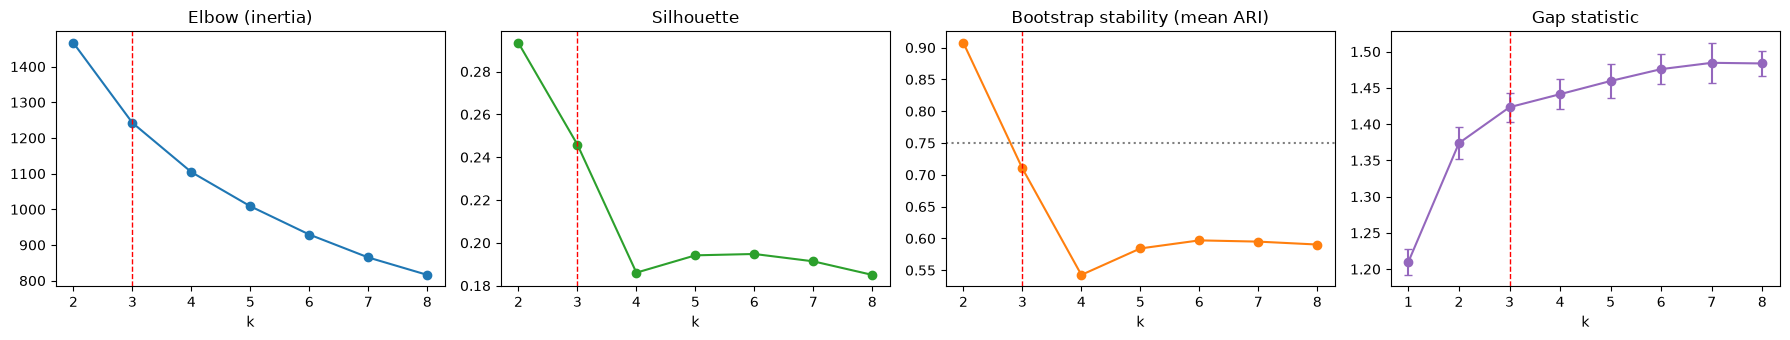

In [55]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
axes[0].plot(seg_table.index, seg_table["inertia"], "o-")
axes[0].set(title="Elbow (inertia)", xlabel="k")
axes[1].plot(seg_table.index, seg_table["silhouette"], "o-", color="tab:green")
axes[1].set(title="Silhouette", xlabel="k")
axes[2].plot(seg_table.index, seg_table["stability"], "o-", color="tab:orange")
axes[2].axhline(MIN_STABILITY, color="grey", ls=":")
axes[2].set(title="Bootstrap stability (mean ARI)", xlabel="k")
axes[3].errorbar(range(1, 9), gaps_ws, yerr=gap_sd_ws, fmt="o-", color="tab:purple", capsize=3)
axes[3].set(title="Gap statistic", xlabel="k")
for ax in axes:
    ax.axvline(k_final, color="red", ls="--", lw=1)
plt.tight_layout()
plt.show()

### Step 4 — K-Means vs Ward at the chosen k

In [56]:
km_seg = KMeans(n_clusters=k_final, n_init=10, random_state=SEED).fit(Z_dev)
ward_seg = AgglomerativeClustering(n_clusters=k_final, linkage="ward").fit(Z_dev)
ward_assigner = NearestCentroid().fit(Z_dev, ward_seg.labels_)          # Ward has no predict → nearest centroid
ward_stability = np.mean([
    adjusted_rand_score(ward_seg.labels_, NearestCentroid().fit(
        Z_dev[idx], AgglomerativeClustering(n_clusters=k_final, linkage="ward").fit_predict(Z_dev[idx])).predict(Z_dev))
    for idx in boot_sets])

compare = pd.DataFrame({
    "silhouette": [silhouette_score(Z_dev, km_seg.labels_), silhouette_score(Z_dev, ward_seg.labels_)],
    "Calinski-Harabasz": [calinski_harabasz_score(Z_dev, km_seg.labels_), calinski_harabasz_score(Z_dev, ward_seg.labels_)],
    "Davies-Bouldin": [davies_bouldin_score(Z_dev, km_seg.labels_), davies_bouldin_score(Z_dev, ward_seg.labels_)],
    "stability": [seg_table.loc[k_final, "stability"], ward_stability],
    "sizes": [sorted(np.bincount(km_seg.labels_).tolist(), reverse=True), sorted(np.bincount(ward_seg.labels_).tolist(), reverse=True)],
}, index=["K-Means", "Ward"])
print(compare.round(3))

agree_dev = adjusted_rand_score(km_seg.labels_, ward_seg.labels_)
agree_new = adjusted_rand_score(km_seg.predict(Z_new), ward_assigner.predict(Z_new))
refit_all = KMeans(n_clusters=k_final, n_init=10, random_state=SEED).fit(prep.transform(wholesale[SPEND]))
generalize = adjusted_rand_score(refit_all.predict(Z_new), km_seg.predict(Z_new))
print(f"\nK-Means vs Ward agreement: ARI {agree_dev:.3f} on development customers, {agree_new:.3f} on new customers")
print(f"K-Means fitted on development customers vs refitted on all 440, labels of the new customers: ARI {generalize:.3f}")

stab_diff = compare.loc["K-Means", "stability"] - compare.loc["Ward", "stability"]
winner = compare["stability"].idxmax() if abs(stab_diff) >= 0.02 else compare["silhouette"].idxmax()
print(f"→ Final model: {winner} ({'more stable' if abs(stab_diff) >= 0.02 else 'similar stability, higher silhouette'}"
      f"{', and it can assign new customers with predict()' if winner == 'K-Means' else ''}).")

         silhouette  Calinski-Harabasz  Davies-Bouldin  stability           sizes
K-Means       0.246            122.135           1.366       0.71  [175, 103, 74]
Ward          0.264             98.544           1.625       0.52  [203, 107, 42]

K-Means vs Ward agreement: ARI 0.455 on development customers, 0.549 on new customers
K-Means fitted on development customers vs refitted on all 440, labels of the new customers: ARI 0.921
→ Final model: K-Means (more stable, and it can assign new customers with predict()).


### Step 5 — Profile the segments

We assign **all 440 customers** with the final model and describe segments in the units the business uses. Segments are renamed S1, S2, … in order of median annual spend so the names are stable and meaningful. The **spend index** is the segment's median spend divided by the median of all customers × 100 (100 = typical, 200 = twice the typical customer).

         customers  % customers  % of total spend  median annual spend  % Retail
segment                                                                         
S1             128         29.1              48.5              47001.5      58.6
S2              92         20.9              20.0              28558.5      69.6
S3             220         50.0              31.5              18415.0       1.4

spend index (100 = typical customer):
          Fresh   Milk  Grocery  Frozen  Detergents_Paper  Delicassen
segment                                                             
S1       151.0  197.0    200.0   164.0             362.0       212.0
S2        24.0  193.0    235.0    28.0             557.0        71.0
S3       113.0   44.0     46.0   135.0              33.0        71.0

region mix:
 Region   Lisbon  Oporto  Other
segment                       
S1         0.16    0.06   0.78
S2         0.17    0.13   0.70
S3         0.19    0.12   0.69


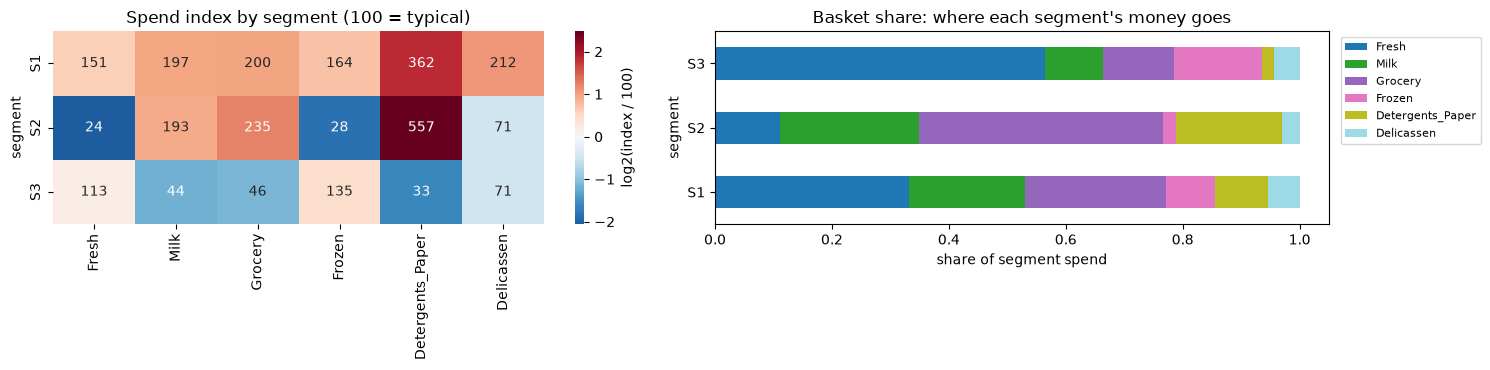

In [57]:
Z_all = prep.transform(wholesale[SPEND])
seg_raw = km_seg.predict(Z_all) if winner == "K-Means" else ward_assigner.predict(Z_all)
ws = wholesale.assign(total=wholesale[SPEND].sum(axis=1), seg_raw=seg_raw)
order = ws.groupby("seg_raw")["total"].median().sort_values(ascending=False).index
ws["segment"] = ws["seg_raw"].map({old: f"S{i + 1}" for i, old in enumerate(order)})

overall_median = ws[SPEND].median()
spend_index = (100 * ws.groupby("segment")[SPEND].median() / overall_median).round(0)
seg_summary = pd.DataFrame({
    "customers": ws["segment"].value_counts().sort_index(),
    "% customers": 100 * ws["segment"].value_counts(normalize=True).sort_index(),
    "% of total spend": 100 * ws.groupby("segment")["total"].sum() / ws["total"].sum(),
    "median annual spend": ws.groupby("segment")["total"].median(),
    "% Retail": 100 * (ws["Channel"] == "Retail").groupby(ws["segment"]).mean(),
})
basket_share = ws.groupby("segment")[SPEND].sum().div(ws.groupby("segment")["total"].sum(), axis=0)
print(seg_summary.round(1))
print("\nspend index (100 = typical customer):\n", spend_index)
print("\nregion mix:\n", pd.crosstab(ws["segment"], ws["Region"], normalize="index").round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 3.8))
sns.heatmap(np.log2(spend_index / 100), annot=spend_index, fmt=".0f", cmap="RdBu_r", center=0, ax=axes[0],
            cbar_kws={"label": "log2(index / 100)"})
axes[0].set_title("Spend index by segment (100 = typical)")
basket_share.plot(kind="barh", stacked=True, ax=axes[1], colormap="tab20")
axes[1].set(title="Basket share: where each segment's money goes", xlabel="share of segment spend")
axes[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### Step 6 — Business-facing descriptions (computed from the profile)

Each description is generated from the numbers above with fixed rules: "over-index" means an index ≥ 150, "under-index" ≤ 67, the channel word comes from the Retail share, a segment that over-indexes on 4+ categories is a "broad basket", and otherwise the suggested focus comes from the category with the highest index. Nothing is typed in by hand, so the text updates if the data or k changes.

In [58]:
FOCUS = {"Fresh": "fresh-produce delivery schedules", "Milk": "dairy bundles", "Grocery": "bulk grocery price tiers",
         "Frozen": "frozen-goods logistics", "Detergents_Paper": "cleaning and paper supply contracts",
         "Delicassen": "premium deli assortments"}
typical_total = ws["total"].median()
for seg in seg_summary.index:
    idx_row = spend_index.loc[seg].sort_values(ascending=False)
    n_over = int((idx_row >= 150).sum())
    over = [f"{c} {idx_row[c]:.0f}" for c in idx_row.index if idx_row[c] >= 150][:3]
    under = [f"{c} {idx_row[c]:.0f}" for c in idx_row.index[::-1] if idx_row[c] <= 67][:3]
    retail = seg_summary.loc[seg, "% Retail"]
    channel_word = "Retail" if retail >= 70 else "Horeca" if retail <= 30 else "mixed-channel"
    size_ratio = seg_summary.loc[seg, "median annual spend"] / typical_total
    scale_word = "Large" if size_ratio >= 1.3 else "Small" if size_ratio <= 0.7 else "Mid-size"
    lead = idx_row.index[0]
    basket_word = "broad basket" if n_over >= 4 else f"{idx_row.index[0]} + {idx_row.index[1]}-led"
    focus = "key-account management and volume discounts" if n_over >= 4 else FOCUS[lead]
    print(f"{seg} — {scale_word} {channel_word} buyers, {basket_word}")
    print(f"   {seg_summary.loc[seg, 'customers']} customers ({seg_summary.loc[seg, '% customers']:.0f}%) generate "
          f"{seg_summary.loc[seg, '% of total spend']:.0f}% of spend; median {seg_summary.loc[seg, 'median annual spend']:,.0f} m.u./year "
          f"({size_ratio:.1f}× the typical customer)")
    print(f"   over-index: {', '.join(over) if over else 'none'} | under-index: {', '.join(under) if under else 'none'} "
          f"| {retail:.0f}% Retail → suggested focus: {focus}")

S1 — Large mixed-channel buyers, broad basket
   128 customers (29%) generate 48% of spend; median 47,002 m.u./year (1.7× the typical customer)
   over-index: Detergents_Paper 362, Delicassen 212, Grocery 200 | under-index: none | 59% Retail → suggested focus: key-account management and volume discounts
S2 — Mid-size mixed-channel buyers, Detergents_Paper + Grocery-led
   92 customers (21%) generate 20% of spend; median 28,558 m.u./year (1.0× the typical customer)
   over-index: Detergents_Paper 557, Grocery 235, Milk 193 | under-index: Fresh 24, Frozen 28 | 70% Retail → suggested focus: cleaning and paper supply contracts
S3 — Small Horeca buyers, Frozen + Fresh-led
   220 customers (50%) generate 31% of spend; median 18,415 m.u./year (0.7× the typical customer)
   over-index: none | under-index: Detergents_Paper 33, Milk 44, Grocery 46 | 1% Retail → suggested focus: frozen-goods logistics


### Step 7 — Rules the sales team can use, and an honesty check

In [59]:
rules_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, random_state=SEED)
rules_tree.fit(wholesale.loc[dev_idx, SPEND], ws.loc[dev_idx, "segment"])
fidelity_new = (rules_tree.predict(wholesale.loc[new_idx, SPEND]) == ws.loc[new_idx, "segment"]).mean()
print(export_text(rules_tree, feature_names=SPEND, decimals=0))
channel_ari = adjusted_rand_score(ws["Channel"], ws["segment"])
print(f"Rule fidelity on held-back new customers: {fidelity_new:.1%}")
print(f"Agreement between segments and the Channel column (never used for clustering): ARI {channel_ari:.3f}")

print("\nConclusions (computed):")
k_stab = seg_table.loc[k_final, "stability"]
print(f"1. k = {k_final} was chosen inside the business range {BUSINESS_RANGE.start}–{BUSINESS_RANGE.stop - 1}; outside that constraint, "
      f"silhouette alone preferred k={seg_table['silhouette'].idxmax()}. Its bootstrap stability is {k_stab:.2f} → "
      + ("above our bar." if k_stab >= MIN_STABILITY else f"below our {MIN_STABILITY} bar, so present the segments as indicative, not final."))
print(f"2. {winner} was kept (stability K-Means {compare.loc['K-Means', 'stability']:.2f} vs Ward {compare.loc['Ward', 'stability']:.2f}); "
      f"the two methods agree with ARI {agree_dev:.2f} → "
      + ("the segments are not an artefact of one algorithm." if agree_dev >= 0.6
         else "moderate agreement: segment cores are shared, but the boundaries depend on the algorithm, so treat borderline customers as soft."))
top_seg = seg_summary["% of total spend"].idxmax()
print(f"3. {top_seg} is the most valuable segment: {seg_summary.loc[top_seg, '% customers']:.0f}% of customers, "
      f"{seg_summary.loc[top_seg, '% of total spend']:.0f}% of spend.")
channel_word = "largely reflect" if channel_ari >= 0.5 else "partly reflect" if channel_ari >= 0.2 else "barely reflect"
print(f"4. Segments {channel_word} the Horeca/Retail split (ARI {channel_ari:.2f}) even though Channel was never an input: "
      "spending patterns carry real information about business type, and segments add detail beyond it.")
print(f"5. A depth-3 rule tree reproduces the segment of {fidelity_new:.0%} of unseen customers, so sales can assign new accounts without the model.")

|--- Grocery <= 4548
|   |--- Milk <= 3902
|   |   |--- Frozen <= 420
|   |   |   |--- class: S3
|   |   |--- Frozen >  420
|   |   |   |--- class: S3
|   |--- Milk >  3902
|   |   |--- Frozen <= 2134
|   |   |   |--- class: S3
|   |   |--- Frozen >  2134
|   |   |   |--- class: S1
|--- Grocery >  4548
|   |--- Frozen <= 982
|   |   |--- Fresh <= 9002
|   |   |   |--- class: S2
|   |   |--- Fresh >  9002
|   |   |   |--- class: S1
|   |--- Frozen >  982
|   |   |--- Milk <= 2796
|   |   |   |--- class: S3
|   |   |--- Milk >  2796
|   |   |   |--- class: S1

Rule fidelity on held-back new customers: 88.6%
Agreement between segments and the Channel column (never used for clustering): ARI 0.383

Conclusions (computed):
1. k = 3 was chosen inside the business range 3–6; outside that constraint, silhouette alone preferred k=2. Its bootstrap stability is 0.71 → below our 0.75 bar, so present the segments as indicative, not final.
2. K-Means was kept (stability K-Means 0.71 vs Ward 0.52); th

**Stretch goals**
1. Add **share-of-basket features** (each category / total) next to log spend, so segments separate *what* customers buy from *how much*. Does the Channel ARI go up?
2. Replace K-Means with a **Gaussian mixture** (next notebook) and use `predict_proba` to flag customers who sit between two segments.
3. Keep segment names consistent across a monthly refresh: match new centroids to old ones with `scipy.optimize.linear_sum_assignment`.
4. Try `RobustScaler` instead of `StandardScaler` and measure the effect on stability.
5. Build a **consensus clustering**: a co-association matrix over the 20 bootstrap runs, then average-linkage clustering on it.

### 🗣️ How to talk about this in an interview
- "I clustered on log-transformed, standardized spend inside a pipeline, because money is right-skewed and log distances compare ratios; without the log, K-Means isolated a few giant accounts."
- "I chose k with several signals — elbow, silhouette, CH, DB, gap, and bootstrap stability — and a business constraint agreed up front (3–6 actionable segments, none under 5%). I didn't just take the silhouette maximum, and I reported honestly when no k met every bar."
- "I compared K-Means with Ward at the same k, reported how much they agree, and kept the more stable one. Because agglomerative clustering has no predict, I used a nearest-centroid assigner."
- "I held back 20% of customers to check that segments generalize, profiled segments with spend indices and basket shares, and generated the descriptions from the numbers so they stay honest on refresh."
- "Channel was never an input, so its agreement with the segments was an independent sanity check. A shallow rule tree gives the sales team a way to assign new accounts."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Explain K-Means. What does it optimize?**

<details><summary>Show answer</summary>

- **30-second answer:** It partitions data into k clusters by minimizing inertia, the within-cluster sum of squared distances $\sum_i \lVert x_i - \mu_{c_i}\rVert^2$. Lloyd's algorithm alternates assigning points to the nearest centroid and moving each centroid to the mean of its points until assignments stop changing.
- **Go deeper:** Each step never increases inertia (the nearest centroid minimizes each point's term; the mean minimizes squared distances), so it converges in finitely many steps, but to a local optimum; the global problem is NP-hard. Cost is $O(nkd)$ per iteration. It is the hard-assignment limit of a Gaussian mixture with equal spherical covariances.
- **❌ Common wrong answer:** "It minimizes the distance between clusters" or "it finds the globally optimal clusters".

</details>

**Q2. How do you choose k?**

<details><summary>Show answer</summary>

- **30-second answer:** Not by minimum inertia, which always decreases with k. Use the elbow as a rough guide, the silhouette (mean and per-point plot), the gap statistic or Calinski–Harabasz/Davies–Bouldin, then bootstrap stability and whether the business can act on the clusters.
- **Go deeper:** The criteria often disagree (on the penguins, silhouette chose k=2 while species need 3), so shortlist values and decide with stability plus domain constraints stated up front. Gap statistic can say k=1. For hierarchical clustering, cut in the largest merge-height gap. Model-based methods (GMM) let you use BIC.
- **❌ Common wrong answer:** "Pick the k with the lowest inertia" or "the elbow always gives the right answer".

</details>

**Q3. What is k-means++ and why is it the default?**

<details><summary>Show answer</summary>

- **30-second answer:** A seeding method: the first centroid is random, each next centroid is sampled with probability proportional to the squared distance to the nearest centroid already chosen. It spreads the starting centroids out, so K-Means converges faster and to better solutions.
- **Go deeper:** Arthur & Vassilvitskii (2007) prove the expected cost after seeding is $O(\log k)$ times the optimum. scikit-learn uses a greedy variant (several candidates per step). On the digits we measured lower starting inertia, a lower spread of final inertia and a much better worst run than random initialization. Restarts (`n_init`) still help. For huge data, k-means|| (scalable k-means++) samples in parallel rounds.
- **❌ Common wrong answer:** "k-means++ is a different clustering algorithm" or "it guarantees the global optimum".

</details>

**Q4. Why must features be scaled for K-Means and hierarchical clustering?**

<details><summary>Show answer</summary>

- **30-second answer:** Both rely on Euclidean distances, where each feature's squared difference adds up; a feature in large units (grams, dollars) dominates. Standardize, and log-transform skewed amounts first.
- **Go deeper:** On the penguins, body mass held over 99% of the raw variance and unscaled K-Means formed body-mass bands with much lower ARI. Put the scaler inside a pipeline so new data gets the same transform. Also consider feature weighting when some features matter more to the business.
- **❌ Common wrong answer:** "Scaling only speeds up convergence; the clusters are the same."

</details>

**Q5. When does K-Means fail, and what would you use instead?**

<details><summary>Show answer</summary>

- **30-second answer:** Non-convex shapes (moons, rings), elongated clusters, very different sizes or spreads, heavy noise/outliers, and unscaled or categorical features. Use DBSCAN/HDBSCAN for arbitrary shapes and noise, Gaussian mixtures with full covariance for elliptical clusters of different sizes, and k-modes/k-prototypes or Gower distance with hierarchical clustering for categoricals.
- **Go deeper:** The root cause is the Voronoi partition: boundaries are straight lines halfway between centroids, ignoring cluster spread. Each point must belong to a cluster, so outliers drag centroids (K-Medoids is more robust). We demonstrated every failure with ARI on controlled data.
- **❌ Common wrong answer:** "Just increase k until it works."

</details>

**Q6. Compare single, complete, average and Ward linkage.**

<details><summary>Show answer</summary>

- **30-second answer:** Single uses the closest pair (finds chains and curved shapes but suffers chaining), complete the farthest pair (compact, similar-diameter clusters, outlier-sensitive), average the mean of all pairs (a compromise), Ward merges the pair that least increases total within-cluster SSE (K-Means-like, Euclidean only).
- **Go deeper:** Single linkage equals cutting the minimum spanning tree. Ward's merge cost is $\frac{|A||B|}{|A|+|B|}\lVert\mu_A-\mu_B\rVert^2$; SciPy reports $\sqrt{2\Delta}$ as the height. Distances after merges are updated with the Lance–Williams formula. On the penguins, complete/average beat Ward and K-Means, while single linkage chained Adelie and Chinstrap into one cluster.
- **❌ Common wrong answer:** "Linkage is the distance metric" (it's how point distances are combined into cluster distances).

</details>

**Q7. K-Means vs hierarchical clustering: how do you choose?**

<details><summary>Show answer</summary>

- **30-second answer:** K-Means for large data, when you know or can pick k and need to assign new points. Hierarchical for smaller data (thousands of rows), when you want a full tree, don't know k, need non-Euclidean distances, or need connectivity constraints.
- **Go deeper:** Hierarchical needs $O(n^2)$ memory and at least $O(n^2)$ time, and greedy merges are never undone. K-Means is $O(nkd)$ per iteration and has `predict`. A common hybrid: K-Means with many clusters (e.g. 200) to compress, then hierarchical clustering of the centroids. BisectingKMeans gives a hierarchy top-down at K-Means cost.
- **❌ Common wrong answer:** "Hierarchical is always better because it doesn't need k" (you still choose where to cut).

</details>

**Q8. What's the difference between silhouette, ARI and NMI?**

<details><summary>Show answer</summary>

- **30-second answer:** Silhouette is internal (no labels): it compares each point's mean intra-cluster distance with its mean distance to the nearest other cluster. ARI and NMI are external: they compare a clustering with reference labels, ignoring cluster names. ARI is chance-adjusted pair counting; NMI is normalized mutual information and is not chance-adjusted (use AMI for that).
- **Go deeper:** Random labels get a high raw Rand index and NMI rises with the number of clusters even for random labels, while ARI/AMI stay near 0 (we showed this on digits). Internal metrics favour convex clusters: on two moons, silhouette preferred K-Means while ARI showed single linkage found the truth. Davies–Bouldin (lower better) and Calinski–Harabasz (higher better) are other internal choices.
- **❌ Common wrong answer:** "Use accuracy against the true labels" — cluster IDs are arbitrary.

</details>

**Q9. When would you use MiniBatchKMeans, and what do you give up?**

<details><summary>Show answer</summary>

- **30-second answer:** When data is large or streaming: each step uses a small random batch and updates centroids with a per-centroid learning rate of 1/count, so cost per step doesn't depend on n and `partial_fit` works chunk by chunk. You give up a little quality: a few percent higher inertia.
- **Go deeper:** At k=64 on 581k forest patches we measured several times faster fitting for a few percent higher inertia, and one `partial_fit` pass over 20 chunks. Full KMeans in scikit-learn is already multi-threaded, so on small data mini-batches may not be faster. For GPU or billions of vectors, FAISS k-means.
- **❌ Common wrong answer:** "MiniBatchKMeans gives the same result, just faster."

</details>

**Q10. How do you cluster data with categorical features?**

<details><summary>Show answer</summary>

- **30-second answer:** Plain K-Means isn't a good fit, because the mean of one-hot columns has no meaning and one-hot columns distort distances. Use k-modes (categorical) or k-prototypes (mixed), or compute a Gower distance matrix and use hierarchical clustering with average/complete linkage (or K-Medoids).
- **Go deeper:** Another route is to learn embeddings (e.g. from an autoencoder or entity embeddings) and cluster those. Always weigh numeric vs categorical contributions deliberately, and profile clusters in original categories.
- **❌ Common wrong answer:** "Label-encode the categories as 0, 1, 2 and run K-Means" — that invents an order and distances.

</details>

### 💻 Coding

**Q11. Implement K-Means in NumPy.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  C = X[rng.choice(len(X), k, replace=False)]          # or k-means++
  for _ in range(max_iter):
      labels = ((X[:, None] - C[None]) ** 2).sum(-1).argmin(1)
      new_C = np.array([X[labels == j].mean(0) if np.any(labels == j) else C[j] for j in range(k)])
      if np.allclose(new_C, C): break
      C = new_C
  ```
- **Go deeper:** Use $\lVert x\rVert^2 + \lVert c\rVert^2 - 2x\cdot c$ to avoid the $(n, k, d)$ array; handle empty clusters; add k-means++ and `n_init` restarts. Our scratch version matched scikit-learn's labels and inertia exactly from the same initial centroids (with `tol=0`).
- **❌ Common wrong answer:** Forgetting empty clusters (NaN centroids) or using a loop over points for the assignment step.

</details>

### 🐛 Debugging Scenarios

**Q12. Your K-Means segmentation gives one huge cluster and two clusters of 3 customers each. What's wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** Probably skewed, unscaled features and outliers: a few very large accounts dominate the distances, so K-Means spends clusters on them. Log-transform amounts, standardize, consider RobustScaler or clipping outliers, and check cluster sizes.
- **Go deeper:** We reproduced it on the wholesale data (standardizing alone left tiny clusters; log1p fixed it). Also check for duplicate IDs, mixed units, and one-hot columns swamping numeric ones. If outliers are the interesting part, use HDBSCAN or treat them separately.
- **❌ Common wrong answer:** "Increase k until the clusters look balanced."

</details>

**Q13. Every time the pipeline reruns, the segment called "cluster 2" describes different customers. How do you fix it?**

<details><summary>Show answer</summary>

- **30-second answer:** Cluster IDs are arbitrary and change with initialization or new data. Fix `random_state` for reproducibility, and on refresh match new centroids to the previous ones with the Hungarian algorithm (`linear_sum_assignment` on the centroid distance matrix), or name segments by a stable property (e.g. order by spend).
- **Go deeper:** Also monitor stability: ARI between consecutive refreshes on the same customers, and track segment sizes and centroid drift. Big changes mean the data shifted or the clustering is unstable (check bootstrap ARI).
- **❌ Common wrong answer:** "Set the random seed" alone — new data can still reorder clusters.

</details>

**Q14. `silhouette_score` runs out of memory / takes forever on 2 million rows. What do you do?**

<details><summary>Show answer</summary>

- **30-second answer:** Silhouette needs all pairwise distances, $O(n^2)$. Use `silhouette_score(..., sample_size=10_000, random_state=...)`, repeat on a few samples and report mean ± std, or use Calinski–Harabasz / Davies–Bouldin, which are $O(nk)$.
- **Go deeper:** In Pitfall 5 the time grew several-fold each time n doubled (heading towards 4×), while a 2,000-row sample estimated the full score within a few thousandths. Stratify the sample by cluster if some clusters are tiny.
- **❌ Common wrong answer:** "Buy a bigger machine" or "skip evaluation".

</details>

### 🏗️ Design

**Q15. Design a customer segmentation system for an e-commerce company.**

<details><summary>Show answer</summary>

- **30-second answer:** Define the business use first (campaigns, pricing, churn prevention). Build behavioural features (RFM: recency, frequency, monetary value, category mix), log-transform and scale in a pipeline, choose k with metrics + stability + a business constraint, profile segments into names and actions, and deploy an assigner (K-Means `predict`) with a scheduled refresh.
- **Go deeper:** Validate with A/B tests of segment-specific actions, not just silhouette. Keep IDs consistent across refreshes (Hungarian matching), monitor segment sizes/centroid drift and stability, and version features and models together. For millions of users use MiniBatchKMeans or Spark; for soft membership use a GMM; handle new customers with too little history as a separate "cold start" segment.
- **❌ Common wrong answer:** "Run K-Means with k=5 on all columns and hand the cluster IDs to marketing."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Every answer was verified by running it with the versions in the header.)

**1.** `adjusted_rand_score([0, 0, 1, 1], [1, 1, 0, 0])`
<details><summary>Answer</summary>

`1.0` — the same grouping with swapped names.
</details>

**2.** What does `silhouette_score([[0], [1], [2]], [0, 0, 0])` do?
<details><summary>Answer</summary>

It raises `ValueError` — the silhouette needs between 2 and n−1 clusters, because $b(i)$ is undefined with one cluster.
</details>

**3.** `hasattr(AgglomerativeClustering(), "predict")`
<details><summary>Answer</summary>

`False` — agglomerative clustering only has `fit` / `fit_predict`. Assign new points with a classifier such as `NearestCentroid` trained on the labels.
</details>

**4.** `linkage([[0], [1], [5]], method="single")[:, 2]`
<details><summary>Answer</summary>

`array([1., 4.])` — 0 and 1 merge at distance 1; then {0, 1} and 5 merge at the closest-pair distance 4.
</details>

**5.** `KMeans(n_clusters=2, n_init=10, random_state=0).fit([[0], [1], [10], [11]]).inertia_`
<details><summary>Answer</summary>

`1.0` — centroids at 0.5 and 10.5; each of the 4 points is 0.5 away: 4 × 0.25 = 1.
</details>

## 📚 Resources

### 📖 Official Docs
- [scikit-learn — 2.3. Clustering](https://scikit-learn.org/stable/modules/clustering.html) — every algorithm plus the "Clustering performance evaluation" section on ARI, NMI, silhouette, CH and DB
- [SciPy — Hierarchical clustering (scipy.cluster.hierarchy)](https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html) — `linkage`, `dendrogram`, `fcluster`, `cophenet`
- [scikit-learn example — Demonstration of k-means assumptions](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_assumptions.html) — the failure modes of Section 6
- [scikit-learn example — Selecting the number of clusters with silhouette analysis on KMeans clustering](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html) — silhouette plots in detail
- [scikit-learn example — Comparing different hierarchical linkage methods on toy datasets](https://scikit-learn.org/stable/auto_examples/cluster/plot_linkage_comparison.html) — single/complete/average/Ward side by side
- [UCI Machine Learning Repository — Wholesale customers](https://archive.ics.uci.edu/dataset/292/wholesale+customers) — the mini project's data and its documentation (CC BY 4.0)
- [palmerpenguins on GitHub](https://github.com/allisonhorst/palmerpenguins) — the penguins dataset, its origin and licence (CC0)

### 🎥 Videos
- [StatQuest (Josh Starmer) — StatQuest: K-means clustering](https://www.youtube.com/watch?v=4b5d3muPQmA) (~9 min) — Lloyd's algorithm and the elbow plot drawn step by step; watch before Section 2
- [StatQuest (Josh Starmer) — StatQuest: Hierarchical Clustering](https://www.youtube.com/watch?v=7xHsRkOdVwo) (~11 min) — how merges build a dendrogram and how linkage choices change it; watch before Section 8

### 📄 Papers
- [Arthur & Vassilvitskii (2007) — k-means++: The Advantages of Careful Seeding](https://theory.stanford.edu/~sergei/papers/kMeansPP-soda.pdf) — the D² seeding and its $O(\log k)$ guarantee
- [Sculley (2010) — Web-Scale K-Means Clustering](https://www.eecs.tufts.edu/~dsculley/papers/fastkmeans.pdf) — mini-batch K-Means with per-center learning rates
- [Tibshirani, Walther & Hastie (2001) — Estimating the number of clusters in a data set via the gap statistic](https://web.stanford.edu/~hastie/Papers/gap.pdf) — the gap statistic and its 1-standard-error rule
- [Rousseeuw (1987) — Silhouettes: a graphical aid to the interpretation and validation of cluster analysis](https://www.sciencedirect.com/science/article/pii/0377042787901257) — the original silhouette paper
- [Müllner (2011) — Modern hierarchical, agglomerative clustering algorithms](https://arxiv.org/abs/1109.2378) — fast algorithms behind SciPy's `linkage`

### 📘 Books & Courses
- [An Introduction to Statistical Learning (free PDF)](https://www.statlearning.com/) — Chapter 12 covers K-Means and hierarchical clustering with clear figures
- [Python Data Science Handbook — In Depth: k-Means Clustering](https://jakevdp.github.io/PythonDataScienceHandbook/05.11-k-means.html) — Jake VanderPlas, with colour-compression and digits examples
- [mlcourse.ai — Topic 7. Unsupervised learning: PCA and clustering](https://mlcourse.ai/book/topic07/topic7_pca_clustering.html) — clustering math with exercises
- [Coursera — Unsupervised Learning, Recommenders, Reinforcement Learning](https://www.coursera.org/learn/unsupervised-learning-recommenders-reinforcement-learning) — Andrew Ng's Machine Learning Specialization, week 1 covers K-Means

### 🏋️ Practice
- [Kaggle — Clustering With K-Means](https://www.kaggle.com/code/ryanholbrook/clustering-with-k-means) — K-Means cluster labels as features, in the browser
- [Kaggle Learn — Feature Engineering Tutorials](https://www.kaggle.com/learn/feature-engineering) — the course that lesson belongs to, with exercises

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Clustering | groups similar rows without labels | judge with internal metrics, external labels (if any), stability, usefulness |
| K-Means objective | minimize within-cluster squared distance | $J = \sum_i \lVert x_i - \mu_{c_i}\rVert^2$, `KMeans(n_clusters, n_init, random_state).inertia_` |
| Lloyd's algorithm | assign to nearest centroid ↔ move centroid to mean | never increases $J$; local optimum; $O(nkd)$ per iteration |
| k-means++ | spread-out starting centroids | $P(x) \propto D(x)^2$, `init="k-means++"`, `kmeans_plusplus` |
| Choosing k | elbow, silhouette, gap, CH/DB, stability | `silhouette_score`, `silhouette_samples`, gap = $\mathbb{E}^*[\log W_k] - \log W_k$ |
| Scaling | stop large-unit features dominating | `make_pipeline(FunctionTransformer(np.log1p), StandardScaler(), KMeans(...))` |
| Failure modes | non-convex, elongated, unequal size/spread, noise | Voronoi boundaries → DBSCAN/HDBSCAN, GMM (next notebook) |
| MiniBatchKMeans | batches + per-centroid rate 1/count | `MiniBatchKMeans(batch_size=4096)`, `partial_fit(chunk)` |
| Agglomerative | merge closest clusters bottom-up | `AgglomerativeClustering(linkage=...)`, `linkage(X, method)` |
| Linkages | single=min, complete=max, average=mean, Ward=ΔSSE | Ward $\Delta = \frac{|A||B|}{|A|+|B|}\lVert\mu_A-\mu_B\rVert^2$, SciPy height $\sqrt{2\Delta}$ |
| Dendrogram & cut | tree of merges; cut for flat clusters | `dendrogram`, `fcluster(Z, k, "maxclust")`, `distance_threshold`, `cophenet` |
| Connectivity | only merge neighbouring clusters | `connectivity=kneighbors_graph(coords, 10)` |
| Internal metrics | compactness/separation, no labels | silhouette ↑, `davies_bouldin_score` ↓, `calinski_harabasz_score` ↑ |
| External metrics | agreement with reference labels | `adjusted_rand_score`, `normalized_mutual_info_score`, `adjusted_mutual_info_score` |
| Profiling | turn clusters into segments | sizes, medians, z-score/index heatmap, crosstabs, surrogate tree, bootstrap ARI |
| New points | assign after clustering | `KMeans.predict`; agglomerative → `NearestCentroid().fit(X, labels)` |

## ➡️ What's Next

**[13 · Clustering II — DBSCAN and Gaussian Mixtures](13_Clustering_DBSCAN_and_Gaussian_Mixtures.ipynb)** — K-Means and Ward assume round, similar clusters and force every point into a group. Next you'll find clusters of any shape and flag noise with DBSCAN and HDBSCAN, and learn soft, probabilistic clustering with Gaussian mixtures and the EM algorithm.